In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

In [2]:
df = pd.read_csv('../Village_Wise_Data/Rora.csv')

In [3]:
df.head()

,Timestamp,Survey type,Village Name,Household ID (House No.),Name of Head of Household,Gender,Contact Number of Household,Social Category,Total Family Members,Main Occupation,...,Livelihood Schemes [PM Fasal Bima],Livelihood Schemes [Pension Schemes],Awareness about Gram Sabha meetings,Participation in village development,Major village issues,Most urgent need of the village,Suggestions for village development,Enumerator Name,UID,Date
0,1/14/2026 11:46:03,Baseline,Rora,NaN,Karmjeet singh,Male,NaN,General,8.0,Agriculture,...,Not Aware,Not Aware,Yes,Regular,"Water, Health, Education, Employment, Environment",Medical,Medical facilities,Sakshi Singh,25MSC10056,1/14/2026
1,1/14/2026 11:49:32,Baseline,Rora,105,Bhupinder Singh,Male,8.729058e+09,OBC,7.0,Agriculture,...,Not Aware,Aware,Yes,Regular,"Water, Environment",Cleanliness and overflow situation of village ...,Cleanliness of ponds,Gurkirat Singh,25BSH70029,1/14/2026
2,1/14/2026 11:51:33,Baseline,Rora,NaN,Jang singh,Male,6.280001e+09,General,4.0,Agriculture,...,Aware,Aware,Yes,Occasional,Employment,Hospital,Dispencery needed,Priyanshu,25MSC1032,1/14/2026
3,1/14/2026 11:51:46,Baseline,Rora,NaN,Ranveer kaur,Female,9.914764e+09,General,6.0,Agriculture,...,Aware,Aware,Yes,Regular,"Water, Education",Waste management,Need to clean infrastructure,Vanshika Sharma,25bsh70062,1/14/2026
4,1/14/2026 11:54:07,Baseline,Rora,69,Gurmir Singh,Male,8.360595e+09,OBC,6.0,Agriculture,...,Not Aware,Availed,Yes,Occasional,Employment,Unemployment issues,Absence of greenery,Raman Thakur,25MSC10061,1/14/2026


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (89, 75)


In [5]:
df.columns = df.columns.str.strip()
df['Total Family Members'] = pd.to_numeric(df['Total Family Members'], errors='coerce')

In [6]:
missing_values = df.isnull().sum().reset_index()
missing_values.columns = ['Column Name', 'Missing Count']
missing_values[missing_values['Missing Count'] > 0]

,Column Name,Missing Count
3,Household ID (House No.),74
6,Contact Number of Household,40
8,Total Family Members,1
15,Pregnant women received ANC services,18
17,Nutritional issues of children,85
18,Common diseases,45
27,Type of school,15
30,Reason for dropout,67
31,Access to digital devices,6
42,Drainage system,6


In [7]:
df.columns

Index(['Timestamp', 'Survey type', 'Village Name', 'Household ID (House No.)',
       'Name of Head of Household', 'Gender', 'Contact Number of Household',
       'Social Category', 'Total Family Members', 'Main Occupation',
       'Approx. Annual Household Income',
       'Distance to nearest health facility', 'Type of facility used',
       'ASHA/ANM visit', 'Immunization status of children (0-5)',
       'Pregnant women received ANC services',
       'Last delivery was institutional  (in any hospital)',
       'Nutritional issues  of children', 'Common diseases',
       'Toilet availability', 'Handwashing with soap',
       'Health Schemes   [Ayushman Bharat (PM-JAY)]',
       'Health Schemes   [Janani Suraksha Yojana]',
       'Health Schemes   [Janani Shishu Suraksha Karyakram]',
       'Health Schemes   [Poshan Abhiyaan / ICDS]',
       'Literacy status of household', 'Children enrolled in school',
       'Type of school', 'Distance to nearest school',
       'School dropout case

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 75 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Timestamp                                              89 non-null     object 
 1   Survey type                                            89 non-null     object 
 2   Village Name                                           89 non-null     object 
 3   Household ID (House No.)                               15 non-null     object 
 4   Name of Head of Household                              89 non-null     object 
 5   Gender                                                 89 non-null     object 
 6   Contact Number of Household                            49 non-null     float64
 7   Social Category                                        89 non-null     object 
 8   Total Family Members                                

# Socio-Economic Indicators

# 1. Income Distribution Index

In [9]:
income_counts = df['Approx. Annual Household Income'].value_counts()

In [10]:
percentage_income = (income_counts/income_counts.sum())*100
percentage_income

Approx. Annual Household Income
<1 lakh     30.337079
3-5 lakh    28.089888
1-3 lakh    25.842697
>5 lakh     15.730337
Name: count, dtype: float64

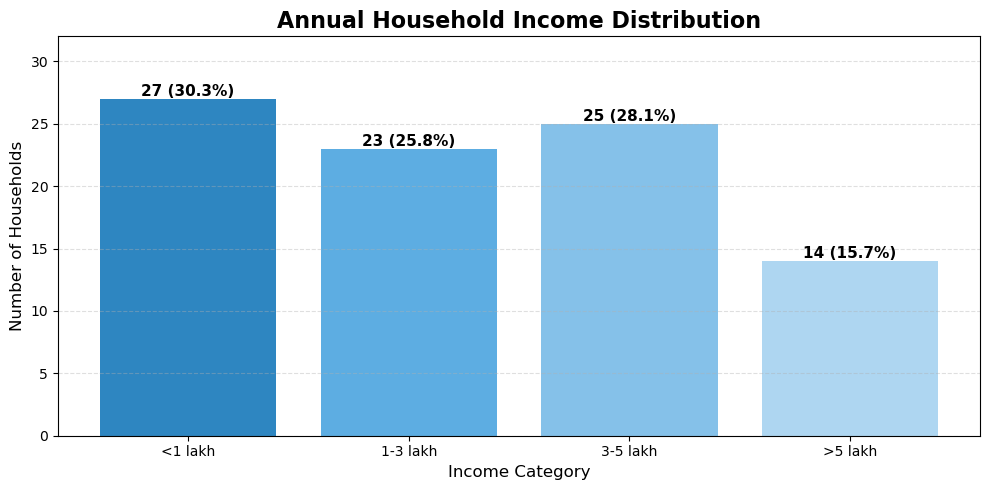

In [11]:
order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']
income_counts = df['Approx. Annual Household Income'].value_counts()
income_counts = income_counts[order]

plt.figure(figsize=(10,5))

colors = ['#2E86C1', '#5DADE2', '#85C1E9', '#AED6F1']
bars = plt.bar(income_counts.index, income_counts.values, color=colors)

total = income_counts.sum()

for bar in bars:
    height = bar.get_height()
    percent = (height / total) * 100
    
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)} ({percent:.1f}%)',
             ha='center',
             va='bottom',
             fontsize=11,
             fontweight='bold')

plt.title("Annual Household Income Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Income Category", fontsize=12)
plt.ylabel("Number of Households", fontsize=12)
plt.ylim(0, income_counts.values.max()+5)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 2. Occupational Diversity Indicator

In [12]:
occupation_dist = df['Main Occupation'].value_counts(normalize=True) * 100
occupation_dist = occupation_dist.round(2)
print(occupation_dist)

Main Occupation
Agriculture              35.96
Labour                   22.47
Business                 12.36
Service                  12.36
Agriculture, Labour       5.62
Agriculture, Service      4.49
Service, Business         3.37
Agriculture, Business     2.25
Labour, Service           1.12
Name: proportion, dtype: float64


In [13]:
df['Main Occupation'].value_counts()

Main Occupation
Agriculture              32
Labour                   20
Business                 11
Service                  11
Agriculture, Labour       5
Agriculture, Service      4
Service, Business         3
Agriculture, Business     2
Labour, Service           1
Name: count, dtype: int64

In [14]:
df['Approx. Annual Household Income'] = df['Approx. Annual Household Income'].str.strip()
df['Main Occupation'] = df['Main Occupation'].str.strip()

In [15]:
order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']
df['Approx. Annual Household Income'] = pd.Categorical(
    df['Approx. Annual Household Income'],
    categories=order,
    ordered=True)

income_occupation = pd.crosstab(
    df['Main Occupation'],
    df['Approx. Annual Household Income'])
income_occupation

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Main Occupation,,,,
Agriculture,8,7,10,7
"Agriculture, Business",0,0,1,1
"Agriculture, Labour",2,1,2,0
"Agriculture, Service",0,0,2,2
Business,1,6,1,3
Labour,14,4,2,0
"Labour, Service",0,1,0,0
Service,2,4,4,1
"Service, Business",0,0,3,0


In [16]:
occupations = df['Main Occupation'].value_counts().index
income_occupation = income_occupation.loc[occupations]
income_occupation

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Main Occupation,,,,
Agriculture,8,7,10,7
Labour,14,4,2,0
Business,1,6,1,3
Service,2,4,4,1
"Agriculture, Labour",2,1,2,0
"Agriculture, Service",0,0,2,2
"Service, Business",0,0,3,0
"Agriculture, Business",0,0,1,1
"Labour, Service",0,1,0,0


In [17]:
top_occupations = df['Main Occupation'].value_counts().head(5).index
income_occupation = income_occupation.loc[top_occupations]

In [18]:
income_occupation

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Main Occupation,,,,
Agriculture,8,7,10,7
Labour,14,4,2,0
Business,1,6,1,3
Service,2,4,4,1
"Agriculture, Labour",2,1,2,0


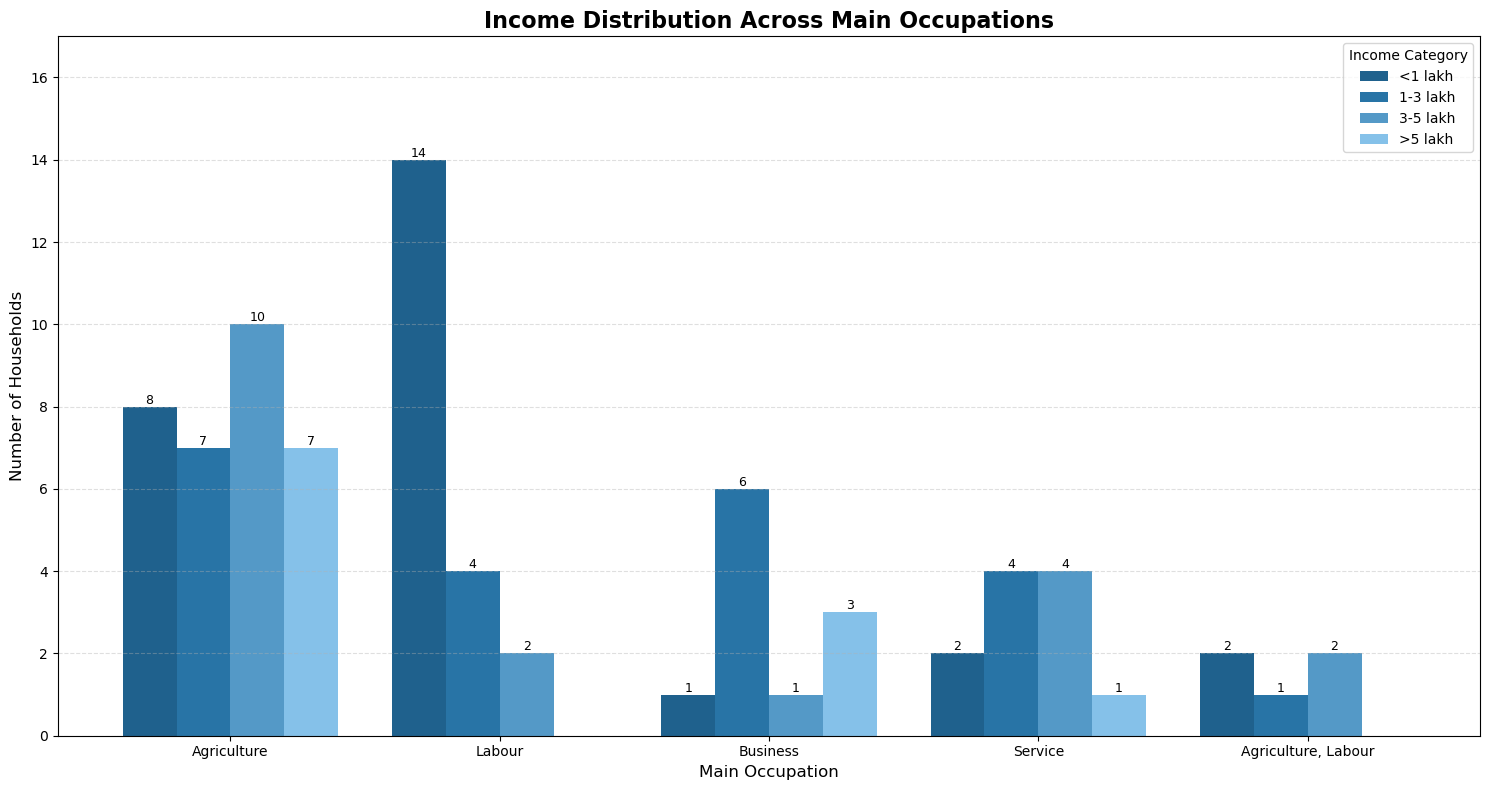

In [19]:
plt.figure(figsize=(15,8))

x = np.arange(len(income_occupation.index))
width = 0.2
colors = ['#1F618D', '#2874A6', '#5499C7', '#85C1E9']

for i, income_cat in enumerate(order):
    bars = plt.bar(x + i*width,
                   income_occupation[income_cat],
                   width,
                   label=income_cat,
                   color=colors[i])
    
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2,
                     height,
                     int(height),
                     ha='center',
                     va='bottom',
                     fontsize=9)

plt.xticks(x + width*1.5, income_occupation.index)
plt.xlabel("Main Occupation", fontsize=12)
plt.ylabel("Number of Households", fontsize=12)
plt.title("Income Distribution Across Main Occupations", fontsize=16, fontweight='bold')

plt.legend(title="Income Category")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.ylim(0, income_occupation.values.max()+3)
plt.tight_layout()
plt.show()

In [20]:
avg_family_size = df['Total Family Members'].mean()
print("Average Family Size:", round(avg_family_size,2))

Average Family Size: 5.59


# 3.Social Inclusion Profile

In [21]:
df['Social Category'].value_counts()

Social Category
General            43
OBC                23
Scheduled Caste    21
Scheduled Tribe     2
Name: count, dtype: int64

In [22]:
social_category = df['Social Category'].value_counts()
per_social_category = round((social_category/social_category.sum())*100,2)
per_social_category

Social Category
General            48.31
OBC                25.84
Scheduled Caste    23.60
Scheduled Tribe     2.25
Name: count, dtype: float64

In [23]:
round(pd.crosstab(df['Social Category'], df['Livelihood Schemes   [PM-KISAN]'], normalize='index') * 100,2)

Livelihood Schemes [PM-KISAN],Applied,Availed,Aware,Not Aware
Social Category,,,,
General,2.33,9.3,46.51,41.86
OBC,4.35,0.0,39.13,56.52
Scheduled Caste,4.76,0.0,52.38,42.86
Scheduled Tribe,0.00,0.0,50.00,50.00


In [24]:
social = df['Social Category'].value_counts()
social = social.sort_values(ascending=False)
total = social.sum()

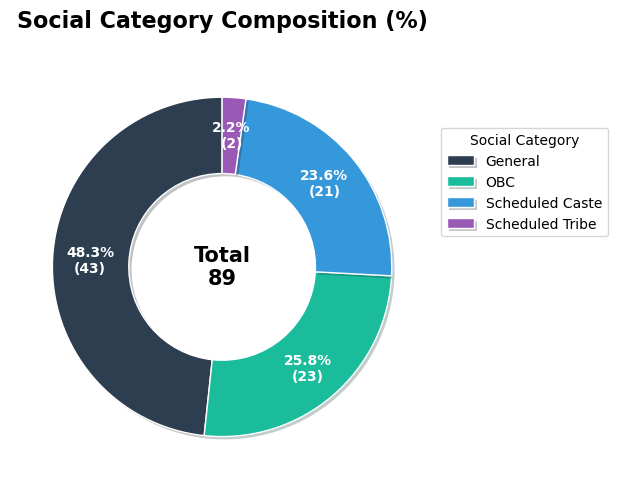

In [25]:
colors = ['#2C3E50', '#1ABC9C', '#3498DB', '#9B59B6']
plt.figure(figsize=(10,5))

wedges, texts, autotexts = plt.pie(social.values, startangle=90, colors=colors, wedgeprops=dict(width=0.45, edgecolor='white'),
                                   pctdistance=0.78, autopct=lambda p: f"{p:.1f}%\n({int(round(p*total/100))})")
for wedge in wedges:
    wedge.set_path_effects([
        pe.SimplePatchShadow(offset=(2, -2), alpha=0.25),
        pe.Normal()])

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

plt.text(0, 0, f"Total\n{total}", ha='center', va='center', fontsize=15, fontweight='bold')
plt.title("Social Category Composition (%)", fontsize=16, fontweight='bold', pad=20)
plt.legend(wedges, social.index, title="Social Category", loc="center left", bbox_to_anchor=(1,0.7))
plt.tight_layout()
plt.show()

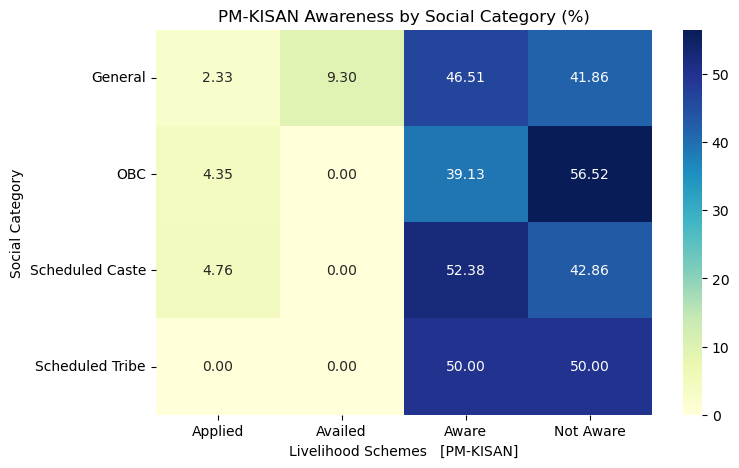

In [26]:
scheme_equity = pd.crosstab(
    df['Social Category'],
    df['Livelihood Schemes   [PM-KISAN]'],
    normalize='index') * 100

plt.figure(figsize=(8,5))
sns.heatmap(scheme_equity,annot=True, cmap="YlGnBu", fmt=".2f")

plt.title("PM-KISAN Awareness by Social Category (%)")
plt.show()

# Health & Nutrition Indicators Framework

# Institutional Delivery Rate

In [27]:
inst_delivery = df['Last delivery was institutional  (in any hospital)'].value_counts(normalize=True) * 100
round(inst_delivery,2)

Last delivery was institutional  (in any hospital)
YES    79.78
No     20.22
Name: proportion, dtype: float64

# Immunization Coverage (0–5 Years)

In [28]:
immunization = df['Immunization status of children (0-5)'].value_counts()
immunization

Immunization status of children (0-5)
Fully            80
Not immunised     6
Partially         3
Name: count, dtype: int64

In [29]:
immunization = df['Immunization status of children (0-5)'].value_counts(normalize=True) * 100
round(immunization,2)

Immunization status of children (0-5)
Fully            89.89
Not immunised     6.74
Partially         3.37
Name: proportion, dtype: float64

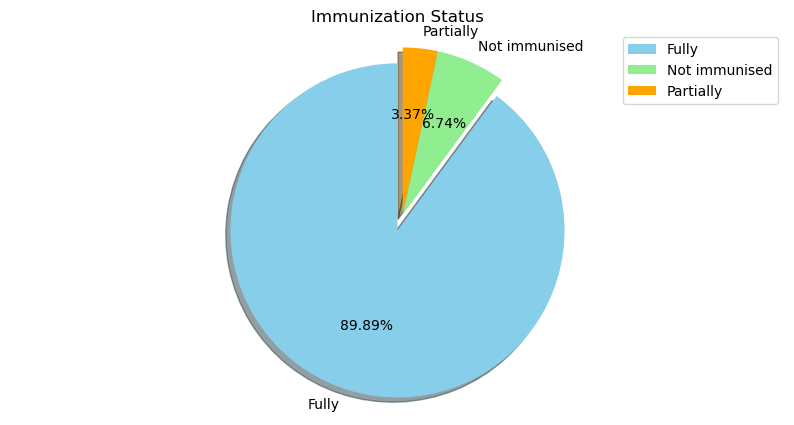

In [30]:
plt.figure(figsize=(10,5))
plt.pie(immunization.values, labels=immunization.index, autopct='%1.2f%%', startangle=90, explode = [0.1, 0, 0], shadow=True,
       colors=['skyblue','lightgreen','orange'])
plt.title("Immunization Status")
plt.axis('equal')
plt.legend()
plt.show()

# Healthcare Accessibility Gap

In [31]:
health_dist = df['Distance to nearest health facility'].value_counts()
health_dist

Distance to nearest health facility
>5 km     38
1-5 km    30
<1 km     21
Name: count, dtype: int64

In [32]:
health_dist = round(df['Distance to nearest health facility'].value_counts(normalize=True) * 100,2)
health_dist

Distance to nearest health facility
>5 km     42.70
1-5 km    33.71
<1 km     23.60
Name: proportion, dtype: float64

In [33]:
order = ['<1 km', '1-5 km', '>5 km']
health_dist = health_dist[order]

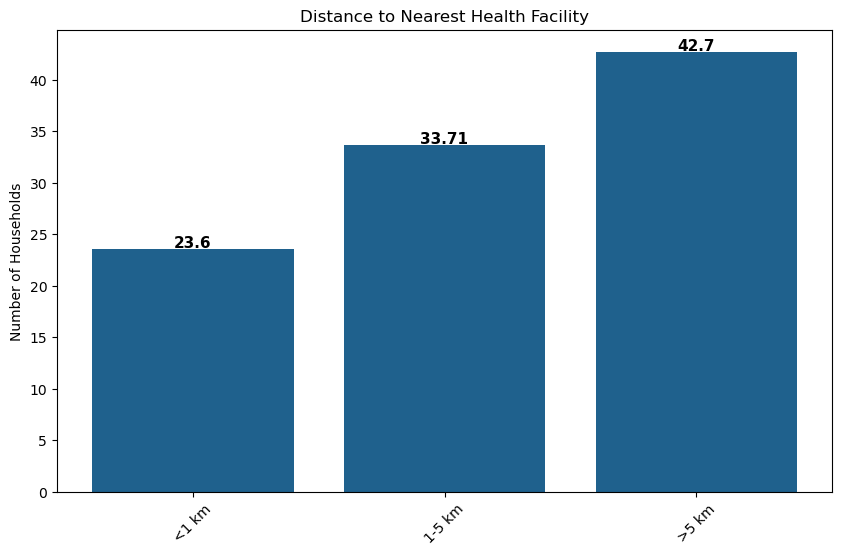

In [34]:
plt.figure(figsize=(10,6))
bars = plt.bar(health_dist.index, health_dist.values, color='#1F618D')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            bar.get_height(),
            ha='center',
            fontsize=11,
            fontweight='bold')
plt.title("Distance to Nearest Health Facility")
plt.ylabel("Number of Households")
plt.xticks(rotation=45)
plt.show()

# Disease Prevalence Rate

In [35]:
df['Common diseases'].value_counts()

Common diseases
BP                           21
BP, Diabetes                 14
Diabetes                      5
BP, Diabetes, Respiratory     2
TB                            1
Diabetes, None                1
Name: count, dtype: int64

In [36]:
diseases_rate = df['Common diseases'].notna().mean() * 100
print(f'Diseases Rate = {round(diseases_rate,2)}%')

Diseases Rate = 49.44%


In [37]:
common_diseases = df['Common diseases'].str.split(',').explode().str.strip()

In [38]:
common_diseases_count = common_diseases.value_counts()
common_diseases_count

Common diseases
BP             37
Diabetes       22
Respiratory     2
TB              1
None            1
Name: count, dtype: int64

In [39]:
common_diseases_percentage = round((common_diseases_count/common_diseases_count.sum())*100,2)
common_diseases_percentage

Common diseases
BP             58.73
Diabetes       34.92
Respiratory     3.17
TB              1.59
None            1.59
Name: count, dtype: float64

# Scheme Awareness & Utilization (Health)

In [40]:
pmjay = round(df['Health Schemes   [Ayushman Bharat (PM-JAY)]'].value_counts(normalize=True) * 100,2)
pmjay

Health Schemes   [Ayushman Bharat (PM-JAY)]
Aware        53.93
Not aware    33.71
Applied       7.87
Availed       4.49
Name: proportion, dtype: float64

In [41]:
jsy = round(df['Health Schemes   [Janani Suraksha Yojana]'].value_counts(normalize=True) * 100,2)
jsy

Health Schemes   [Janani Suraksha Yojana]
Not aware    52.81
Aware        44.94
Availed       2.25
Name: proportion, dtype: float64

# Education & Digital Literacy Indicators

# 1. Household Literacy Rate

In [42]:
literacy = df['Literacy status of household'].value_counts()
literacy

Literacy status of household
All literate          44
Partially literate    32
Mostly illiterate     13
Name: count, dtype: int64

In [43]:
literacy_percent = round(df['Literacy status of household'].value_counts(normalize=True) * 100,2)
literacy_percent

Literacy status of household
All literate          49.44
Partially literate    35.96
Mostly illiterate     14.61
Name: proportion, dtype: float64

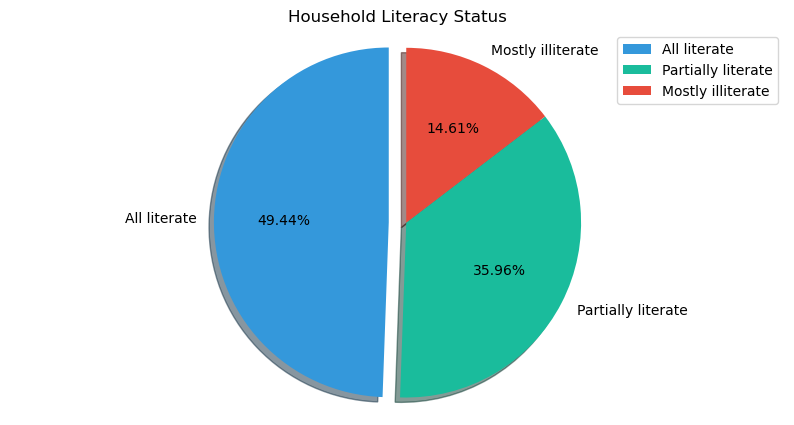

In [44]:
plt.figure(figsize=(10,5))
plt.pie(literacy_percent.values, labels=literacy_percent.index, autopct='%1.2f%%', startangle=90, colors=['#3498DB','#1ABC9C','#E74C3C'], shadow=True,
       explode=[0.1,0,0])
plt.title("Household Literacy Status")
plt.axis('equal')
plt.legend()
plt.show()

# 2. School Dropout Rate

In [45]:
dropout = df['School dropout cases  in the household'].value_counts()
dropout

School dropout cases  in the household
NO        71
YES       15
Partia     3
Name: count, dtype: int64

In [46]:
dropout_percent = round(df['School dropout cases  in the household'].value_counts(normalize=True) * 100,2)
dropout_percent

School dropout cases  in the household
NO        79.78
YES       16.85
Partia     3.37
Name: proportion, dtype: float64

In [47]:
reasons = df['Reason for dropout'].value_counts()
reasons

Reason for dropout
Lack of interest               11
Financial                       7
Domestic work                   2
Financial, Lack of interest     1
Migration                       1
Name: count, dtype: int64

In [48]:
reasons_percent = round(df['Reason for dropout'].value_counts(normalize=True)*100,2)
reasons_percent

Reason for dropout
Lack of interest               50.00
Financial                      31.82
Domestic work                   9.09
Financial, Lack of interest     4.55
Migration                       4.55
Name: proportion, dtype: float64

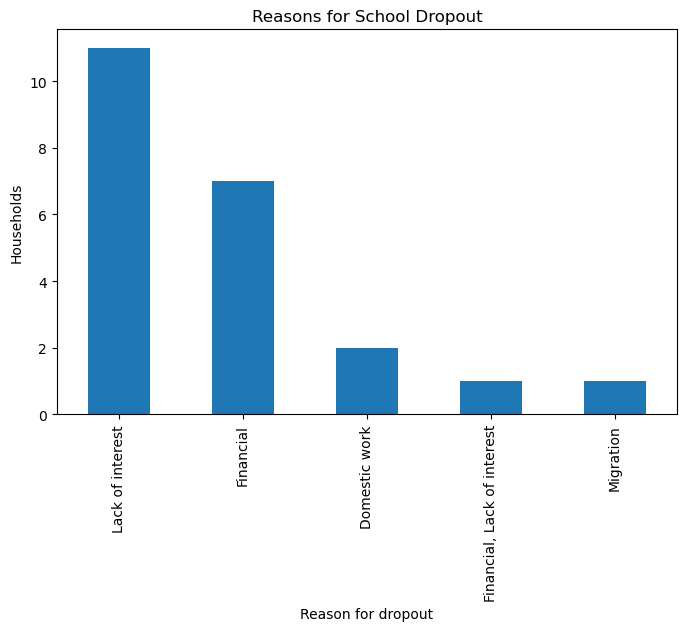

In [49]:
plt.figure(figsize=(8,5))
reasons.plot(kind='bar')
plt.title("Reasons for School Dropout")
plt.ylabel("Households")
plt.xticks(rotation=90)
plt.show()

In [50]:
reasons_strip = df['Reason for dropout'].str.split(',').explode().str.strip()

In [51]:
reasons_value = reasons_strip.value_counts()
reasons_value

Reason for dropout
Lack of interest    12
Financial            8
Domestic work        2
Migration            1
Name: count, dtype: int64

In [52]:
reasons_percentage = round((reasons_value/reasons_value.sum())*100,2)
reasons_percentage

Reason for dropout
Lack of interest    52.17
Financial           34.78
Domestic work        8.70
Migration            4.35
Name: count, dtype: float64

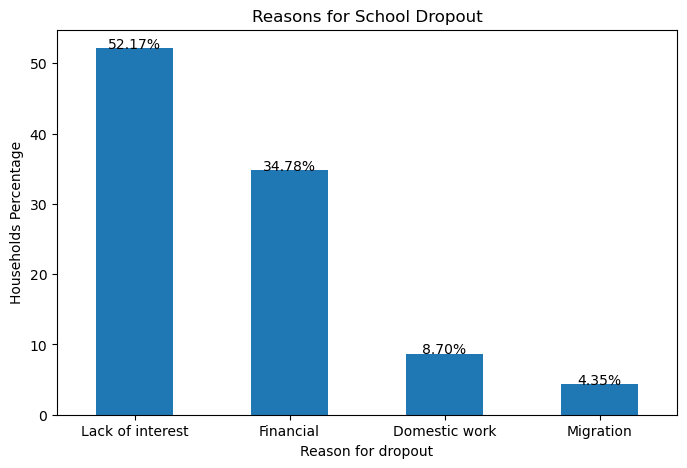

In [53]:
plt.figure(figsize=(8,5))
reasons_percentage.plot(kind='bar')
for i, v in enumerate(reasons_percentage.values):
    plt.text(i, v, f'{v:.2f}%', ha='center')
plt.title("Reasons for School Dropout")
plt.ylabel("Households Percentage")
plt.xticks(rotation=0)
plt.show()

# 3. Digital Divide Index

In [54]:
digital = df['Access to digital devices'].value_counts()
digital

Access to digital devices
Smartphone            61
Smartphone, Laptop    21
Laptop                 1
Name: count, dtype: int64

In [55]:
digital_percent = round(df['Access to digital devices'].value_counts(normalize=True) * 100,2)
digital_percent

Access to digital devices
Smartphone            73.49
Smartphone, Laptop    25.30
Laptop                 1.20
Name: proportion, dtype: float64

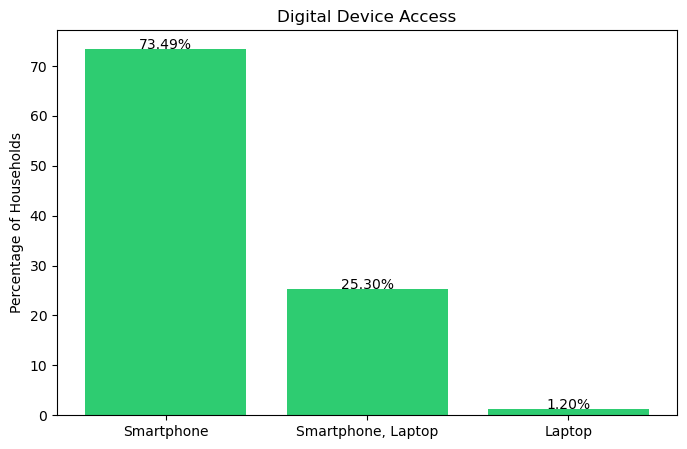

In [56]:
plt.figure(figsize=(8,5))
plt.bar(digital_percent.index, digital_percent.values, color='#2ECC71')
for i,v in enumerate(digital_percent.values):
    plt.text(i, v, f"{v:.2f}%", ha='center')

plt.title("Digital Device Access")
plt.ylabel("Percentage of Households")
plt.show()

In [57]:
digital_values = df['Access to digital devices'].str.split(',').explode().str.strip()

In [58]:
digital_count = digital_values.value_counts()
digital_count

Access to digital devices
Smartphone    82
Laptop        22
Name: count, dtype: int64

In [59]:
digital_percentage = round((digital_count/digital_count.sum())*100,2)
digital_percentage

Access to digital devices
Smartphone    78.85
Laptop        21.15
Name: count, dtype: float64

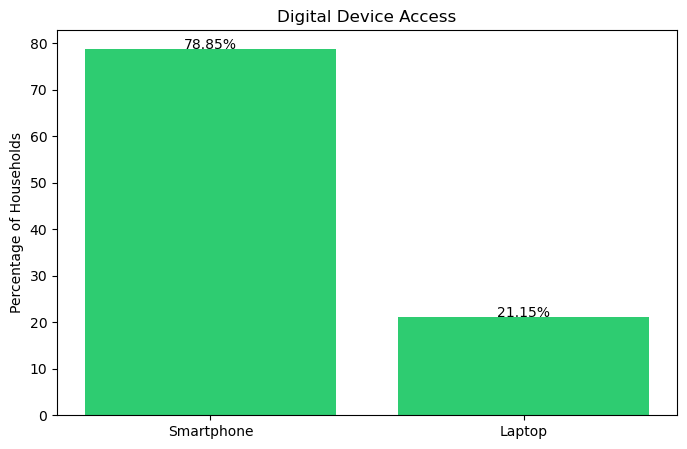

In [60]:
plt.figure(figsize=(8,5))
plt.bar(digital_percentage.index, digital_percentage.values, color='#2ECC71')
for i,v in enumerate(digital_percentage.values):
    plt.text(i, v, f"{v:.2f}%", ha='center')

plt.title("Digital Device Access")
plt.ylabel("Percentage of Households")
plt.show()

# 4. Gender Gap in Higher Education

In [61]:
girls_edu = df['Girls continuing education beyond Class X'].value_counts()
girls_edu

Girls continuing education beyond Class X
YES    78
No     11
Name: count, dtype: int64

In [62]:
girls_edu_percent = round(df['Girls continuing education beyond Class X'].value_counts(normalize=True)*100,2)
girls_edu_percent

Girls continuing education beyond Class X
YES    87.64
No     12.36
Name: proportion, dtype: float64

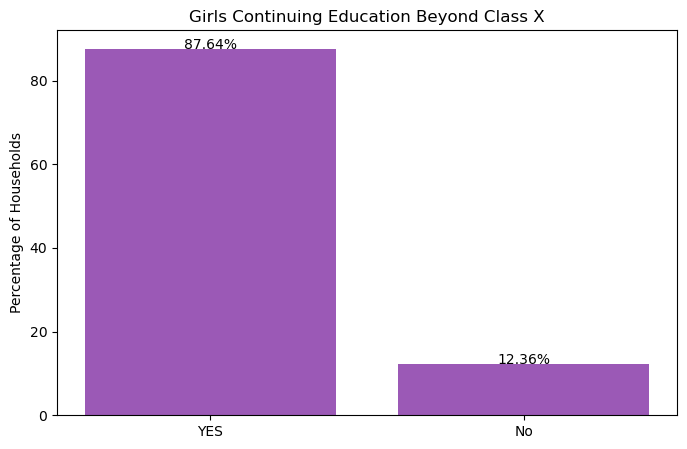

In [63]:
plt.figure(figsize=(8,5))
plt.bar(girls_edu_percent.index, girls_edu_percent.values, color='#9B59B6')

for i,v in enumerate(girls_edu_percent.values):
    plt.text(i, v, f"{v:.2f}%", ha='center')

plt.title("Girls Continuing Education Beyond Class X")
plt.ylabel("Percentage of Households")
plt.show()

# 5. Remedial Support Demand

In [64]:
remedial = df['Need for remedial/coaching support'].value_counts()
remedial

Need for remedial/coaching support
No     45
Yes    44
Name: count, dtype: int64

In [65]:
remedial_percent = round(df['Need for remedial/coaching support'].value_counts(normalize=True)*100,2)
remedial_percent

Need for remedial/coaching support
No     50.56
Yes    49.44
Name: proportion, dtype: float64

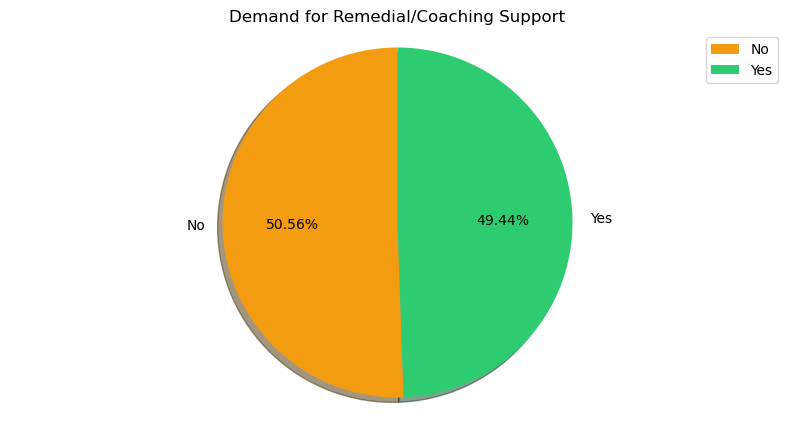

In [66]:
plt.figure(figsize=(10,5))
plt.pie(remedial_percent.values, labels=remedial_percent.index, autopct='%1.2f%%', colors=['#F39C12','#2ECC71'], startangle=90, shadow=True)
plt.title("Demand for Remedial/Coaching Support")
plt.axis('equal')
plt.legend()
plt.show()

# Water, Sanitation & Hygiene (WASH) Indicators

# 1. Safe Drinking Water Access

In [67]:
water_source = df['Source of drinking water'].value_counts()
water_source

Source of drinking water
Tap                  69
Tap, Tanker           6
Tanker                5
Hand pump             3
Hand pump, Tanker     3
Tap, Hand pump        2
Hand pump, Pond       1
Name: count, dtype: int64

In [68]:
water_source_split = df['Source of drinking water'].str.split(',').explode().str.strip()

In [69]:
water_source_count = water_source_split.value_counts()
water_source_count

Source of drinking water
Tap          77
Tanker       14
Hand pump     9
Pond          1
Name: count, dtype: int64

In [70]:
water_source_percentage = round((water_source_count/water_source_count.sum())*100,2)
water_source_percentage

Source of drinking water
Tap          76.24
Tanker       13.86
Hand pump     8.91
Pond          0.99
Name: count, dtype: float64

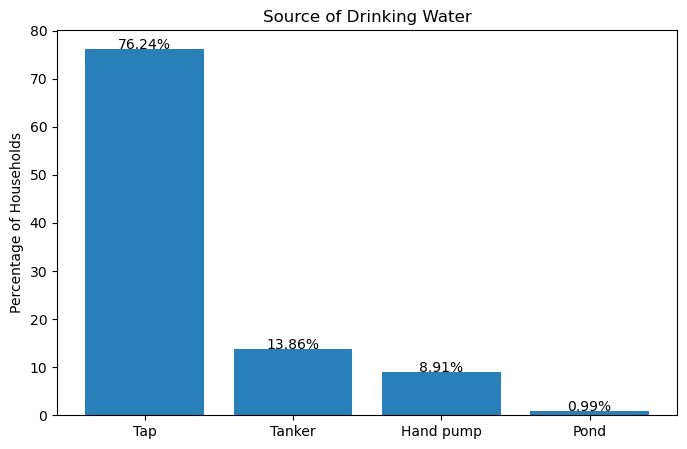

In [71]:
plt.figure(figsize=(8,5))
bars = plt.bar(water_source_percentage.index, water_source_percentage.values, color='#2980B9')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}%",
             ha='center')

plt.title("Source of Drinking Water")
plt.ylabel("Percentage of Households")
plt.xticks()
plt.show()

In [72]:
water_quality = df['Quality of drinking water'].value_counts(normalize=True) * 100
round(water_quality,2)

Quality of drinking water
Good       84.27
Average    15.73
Name: proportion, dtype: float64

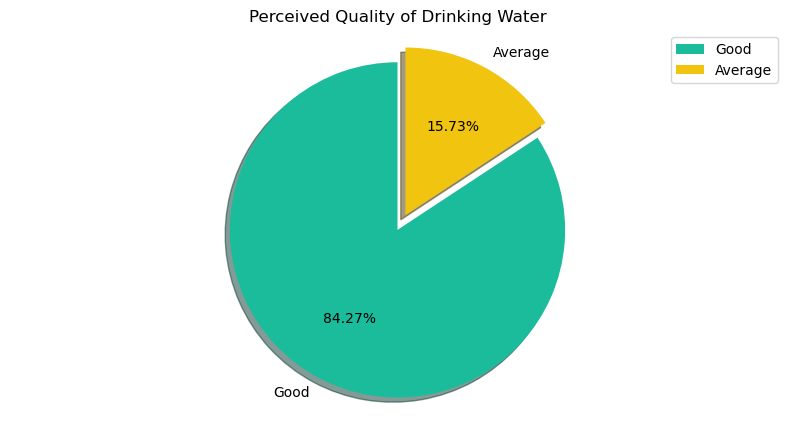

In [73]:
plt.figure(figsize=(10,5))
plt.pie(water_quality.values, labels=water_quality.index, autopct='%1.2f%%', explode=[0.1,0], colors=['#1ABC9C','#F1C40F','#E74C3C'], 
        startangle=90, shadow=True)
plt.title("Perceived Quality of Drinking Water")
plt.axis('equal')
plt.legend()
plt.show()

# 2. Sanitation Coverage

In [74]:
toilet = df['Toilet availability'].value_counts(normalize=True) * 100
round(toilet,2)

Toilet availability
YES    97.75
NO      2.25
Name: proportion, dtype: float64

In [75]:
handwash = df['Handwashing with soap'].value_counts(normalize=True) * 100
round(handwash,2)

Handwashing with soap
Always       89.89
Sometimes     8.99
Rarely        1.12
Name: proportion, dtype: float64

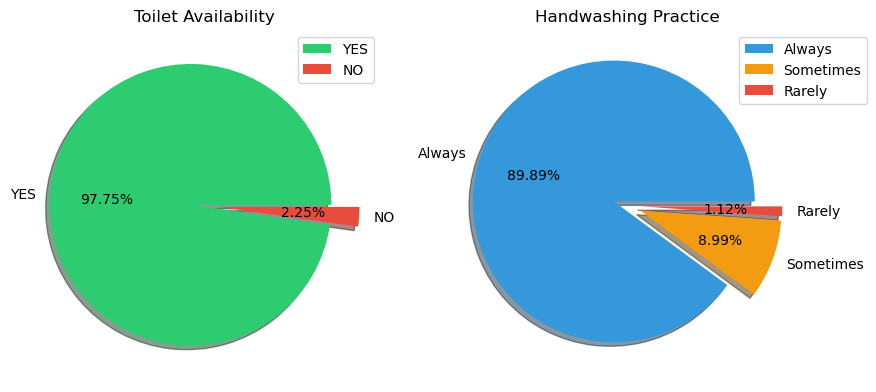

In [76]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.pie(toilet.values, labels=toilet.index, autopct='%1.2f%%',colors=['#2ECC71','#E74C3C'], explode=[0.1,0.1], shadow=True)
plt.title("Toilet Availability")
plt.legend()

plt.subplot(1,2,2)
plt.pie(handwash.values, labels=handwash.index, autopct='%1.2f%%',colors=['#3498DB','#F39C12','#E74C3C'], explode=[0.1,0.1,0.1], shadow=True)
plt.title("Handwashing Practice")
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.show()

# 3. Waste Management Efficiency

In [77]:
waste = df['Solid waste disposal method'].value_counts()
waste

Solid waste disposal method
Open dumping             73
Open dumping, Burning    10
Door-to-door              4
Burning                   2
Name: count, dtype: int64

In [78]:
waste_percent = round(df['Solid waste disposal method'].value_counts(normalize=True)*100,2)
waste_percent

Solid waste disposal method
Open dumping             82.02
Open dumping, Burning    11.24
Door-to-door              4.49
Burning                   2.25
Name: proportion, dtype: float64

In [79]:
waste_split = df['Solid waste disposal method'].str.split(',').explode().str.strip()

In [80]:
waste_split_count = waste_split.value_counts()
waste_split_count

Solid waste disposal method
Open dumping    83
Burning         12
Door-to-door     4
Name: count, dtype: int64

In [81]:
waste_split_percentage = round((waste_split_count / waste_split_count.sum()) * 100, 2)
waste_split_percentage

Solid waste disposal method
Open dumping    83.84
Burning         12.12
Door-to-door     4.04
Name: count, dtype: float64

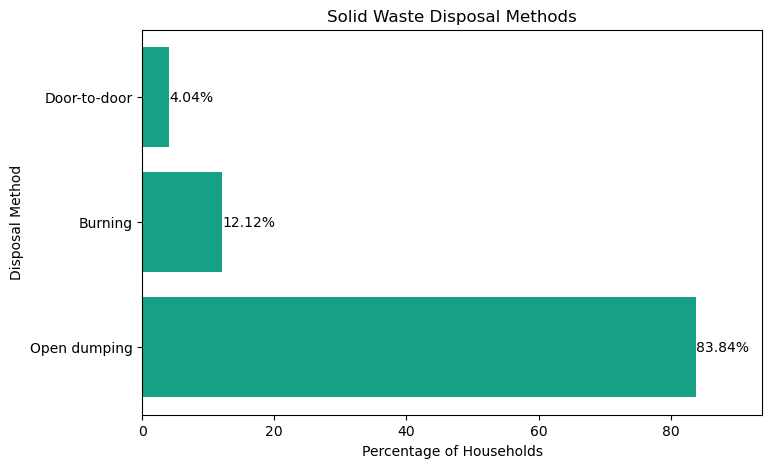

In [82]:
plt.figure(figsize=(8,5))
bars = plt.barh(waste_split_percentage.index, waste_split_percentage.values, color='#16A085')
for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.2f}%",
             va='center')

plt.title("Solid Waste Disposal Methods")
plt.xlabel("Percentage of Households")
plt.ylabel("Disposal Method")
plt.xlim(0,waste_split_percentage.values.max()+10)
plt.show()

# 4.Open Defecation Status

In [83]:
od = df['Open defecation in village'].value_counts(normalize=True) * 100
round(od,2)

Open defecation in village
No     89.89
Yes    10.11
Name: proportion, dtype: float64

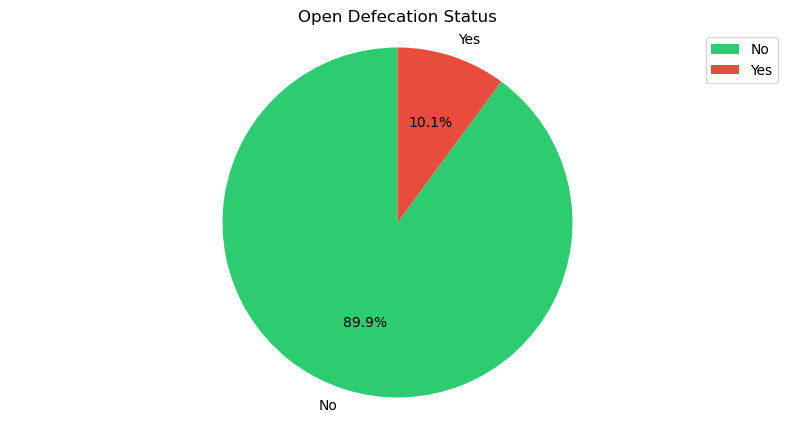

In [84]:
plt.figure(figsize=(10,5))
plt.pie(od.values, labels=od.index, autopct='%1.1f%%', colors=['#2ECC71','#E74C3C'], startangle=90)
plt.title("Open Defecation Status")
plt.axis('equal')
plt.legend()
plt.show()

# Environmental & Disaster Resilience Indicators

# 1. Environmental Stress Index

In [85]:
env_stress = df['Major environmental problems'].value_counts()
env_stress

Major environmental problems
Solid waste                                                 46
Flooding                                                    14
Flooding, Solid waste                                        8
Groundwater depletion, Solid waste                           4
Groundwater depletion                                        3
Groundwater depletion, Crop residue burning, Solid waste     2
Groundwater depletion, Flooding                              2
Groundwater depletion, Flooding, Solid waste                 2
Crop residue burning                                         1
Crop residue burning, Solid waste                            1
Groundwater depletion, Crop residue burning                  1
Groundwater depletion, Crop residue burning, Flooding        1
Groundwater depletion, Soil degradation                      1
Crop residue burning, Soil degradation, Solid waste          1
Soil degradation, Flooding                                   1
Soil degradation, Flooding

In [86]:
env_stress = df['Major environmental problems'].str.split(',').explode().str.strip()

In [87]:
env_stress_counts = env_stress.value_counts()
env_stress_counts

Major environmental problems
Solid waste              65
Flooding                 29
Groundwater depletion    16
Crop residue burning      7
Soil degradation          4
Name: count, dtype: int64

In [88]:
percentage_env_stress_counts = round(env_stress.value_counts(normalize=True)*100,2)
percentage_env_stress_counts

Major environmental problems
Solid waste              53.72
Flooding                 23.97
Groundwater depletion    13.22
Crop residue burning      5.79
Soil degradation          3.31
Name: proportion, dtype: float64

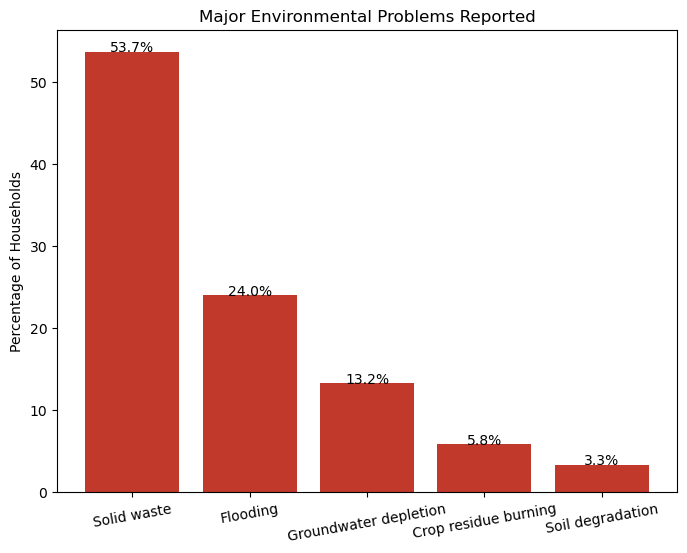

In [89]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_env_stress_counts.index, percentage_env_stress_counts.values, color='#C0392B')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Major Environmental Problems Reported")
plt.ylabel("Percentage of Households")
plt.xticks(rotation=10)
plt.show()

# 2. Renewable Energy Adoption

In [90]:
df['Renewable energy usage'].value_counts()

Renewable energy usage
Solar lights                 36
Biogas                        2
Solar lights, Solar pumps     1
Solar lights, Biogas          1
Name: count, dtype: int64

In [91]:
renewable = df['Renewable energy usage'].str.split(',').explode().str.strip()

In [92]:
renewable_counts = renewable.value_counts()
renewable_counts

Renewable energy usage
Solar lights    38
Biogas           3
Solar pumps      1
Name: count, dtype: int64

In [93]:
percentage_renewable_counts = round(renewable.value_counts(normalize=True)*100,2)
percentage_renewable_counts

Renewable energy usage
Solar lights    90.48
Biogas           7.14
Solar pumps      2.38
Name: proportion, dtype: float64

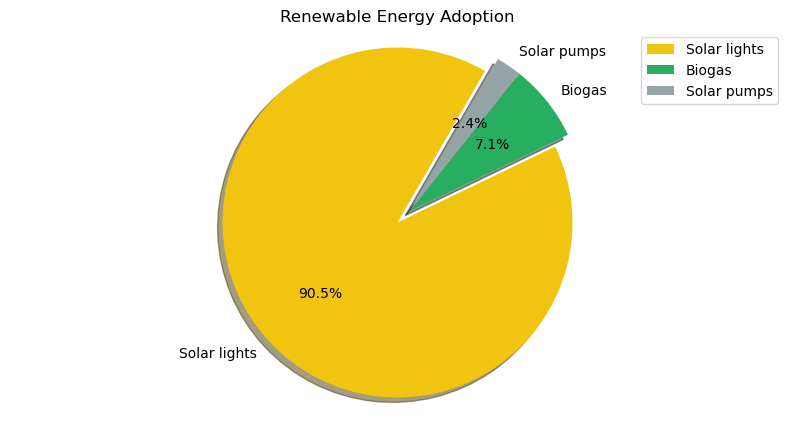

In [94]:
plt.figure(figsize=(10,5))
plt.pie(percentage_renewable_counts.values, labels=percentage_renewable_counts.index, autopct='%1.1f%%', startangle=60, shadow = True,
        colors=['#F1C40F','#27AE60','#95A5A6', '#C0392B'], explode=[0.1,0,0])
plt.title("Renewable Energy Adoption")
plt.legend(loc='upper right')
plt.axis('equal')
plt.show()

# 3. Disaster Vulnerability Score

In [95]:
df['Disaster vulnerability'].value_counts()

Disaster vulnerability
Flood              33
Heatwave           13
Flood, Heatwave     2
Drought             2
Name: count, dtype: int64

In [96]:
disaster = df['Disaster vulnerability'].str.split(',').explode().str.strip()

In [97]:
disaster_count = disaster.value_counts()
disaster_count

Disaster vulnerability
Flood       35
Heatwave    15
Drought      2
Name: count, dtype: int64

In [98]:
disaster_percent = round(disaster.value_counts(normalize=True)*100,2)
disaster_percent

Disaster vulnerability
Flood       67.31
Heatwave    28.85
Drought      3.85
Name: proportion, dtype: float64

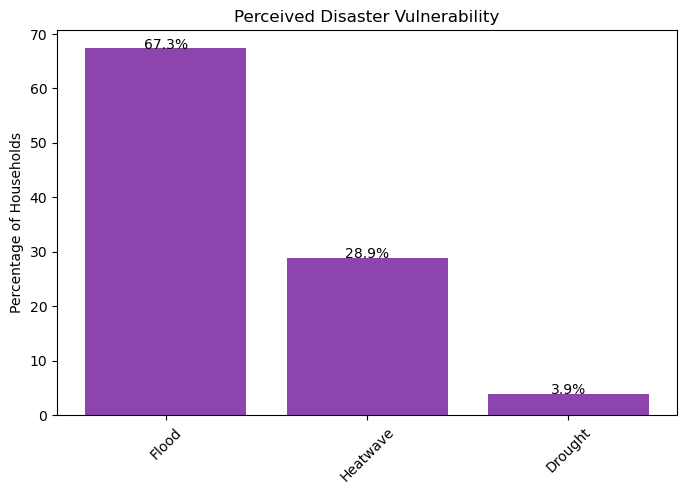

In [99]:
plt.figure(figsize=(8,5))
bars = plt.bar(disaster_percent.index, disaster_percent.values, color='#8E44AD')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Perceived Disaster Vulnerability")
plt.ylabel("Percentage of Households")
plt.xticks(rotation=45)
plt.show()

# 4. Pond Health Status

In [100]:
pond_condition = df['Condition of pond'].value_counts()
pond_condition

Condition of pond
Highly polluted       66
Partially polluted    15
Clean                  8
Name: count, dtype: int64

In [101]:
pond_percent = round(df['Condition of pond'].value_counts(normalize=True)*100,2)
pond_percent

Condition of pond
Highly polluted       74.16
Partially polluted    16.85
Clean                  8.99
Name: proportion, dtype: float64

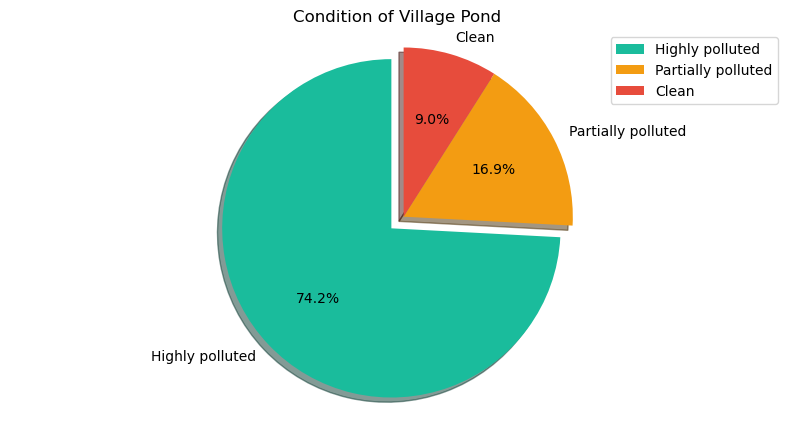

In [102]:
plt.figure(figsize=(10,5))
plt.pie(pond_percent.values, labels=pond_percent.index, autopct='%1.1f%%', colors=['#1ABC9C','#F39C12','#E74C3C'], startangle=90, explode=[0.1,0,0], 
       shadow=True)
plt.title("Condition of Village Pond")
plt.axis('equal')
plt.legend()
plt.show()

# Women Empowerment & Governance Indicators

# Female Labour Force Participation

In [103]:
female_lfp = df['Household women  engaged in income activity'].value_counts()
female_lfp

Household women  engaged in income activity
No     62
Yes    27
Name: count, dtype: int64

In [104]:
percentage_female_lfp = round(df['Household women  engaged in income activity'].value_counts(normalize=True)*100,2)
percentage_female_lfp

Household women  engaged in income activity
No     69.66
Yes    30.34
Name: proportion, dtype: float64

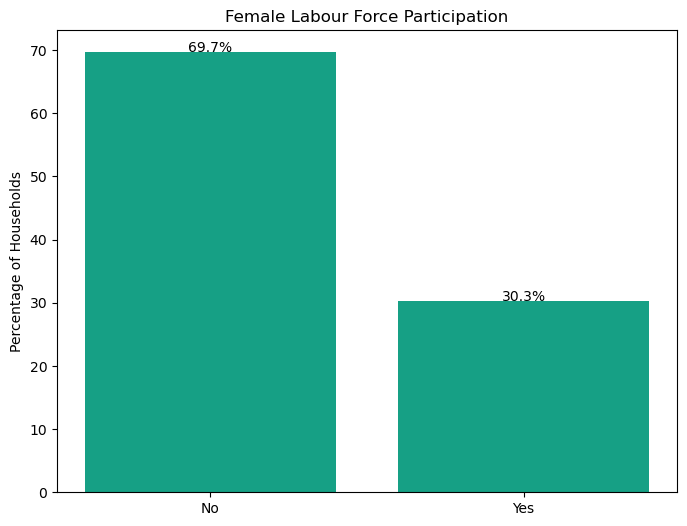

In [105]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_female_lfp.index, percentage_female_lfp.values, color='#16A085')

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')

plt.title("Female Labour Force Participation")
plt.ylabel("Percentage of Households")
plt.show()

# Women Bank Account Ownership

In [106]:
women_bank = df['Bank account in woman’s name'].value_counts()
women_bank

Bank account in woman’s name
Yes    72
No     17
Name: count, dtype: int64

In [107]:
percentage_women_bank = round(df['Bank account in woman’s name'].value_counts(normalize=True)*100,2)
percentage_women_bank

Bank account in woman’s name
Yes    80.9
No     19.1
Name: proportion, dtype: float64

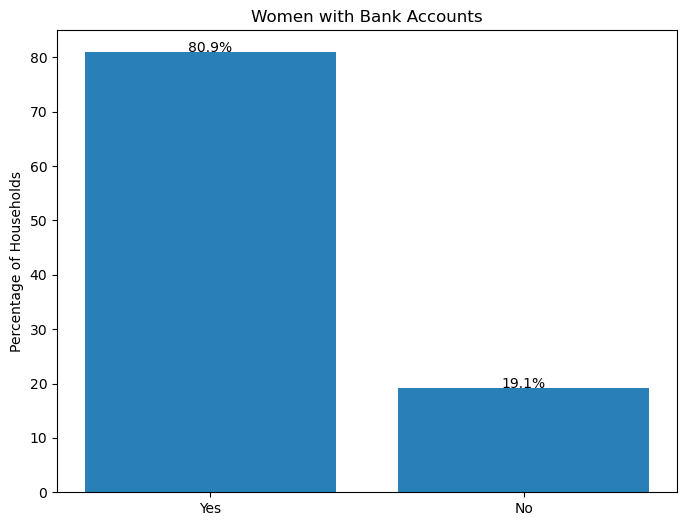

In [108]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_women_bank.index, percentage_women_bank.values, color='#2980B9')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Women with Bank Accounts")
plt.ylabel("Percentage of Households")
plt.show()

# SHG Membership

In [109]:
shg = df['SHG membership'].value_counts()
shg

SHG membership
No     80
Yes     9
Name: count, dtype: int64

In [110]:
percentage_shg = round(df['SHG membership'].value_counts(normalize=True)*100,2)
percentage_shg

SHG membership
No     89.89
Yes    10.11
Name: proportion, dtype: float64

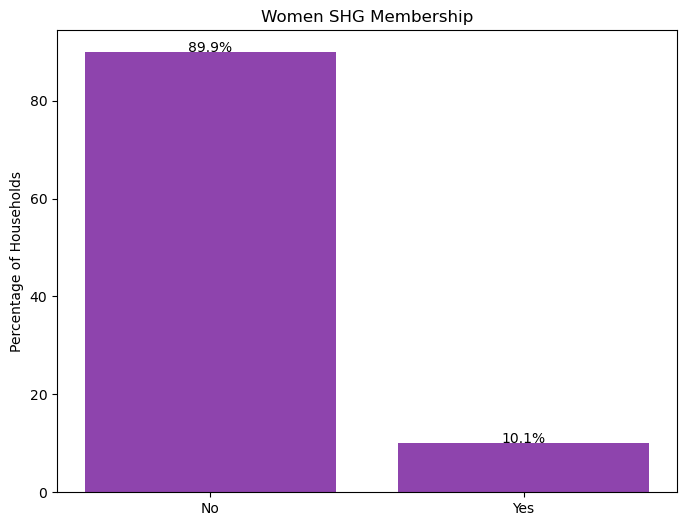

In [111]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_shg.index, percentage_shg.values, color='#8E44AD')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Women SHG Membership")
plt.ylabel("Percentage of Households")
plt.show()

# Governance Awareness (Gram Sabha)

In [112]:
gram_sabha = df['Awareness about Gram Sabha meetings'].value_counts()
gram_sabha

Awareness about Gram Sabha meetings
Yes    69
No     20
Name: count, dtype: int64

In [113]:
percentage_gram_sabha = round(df['Awareness about Gram Sabha meetings'].value_counts(normalize=True)*100,2)
percentage_gram_sabha

Awareness about Gram Sabha meetings
Yes    77.53
No     22.47
Name: proportion, dtype: float64

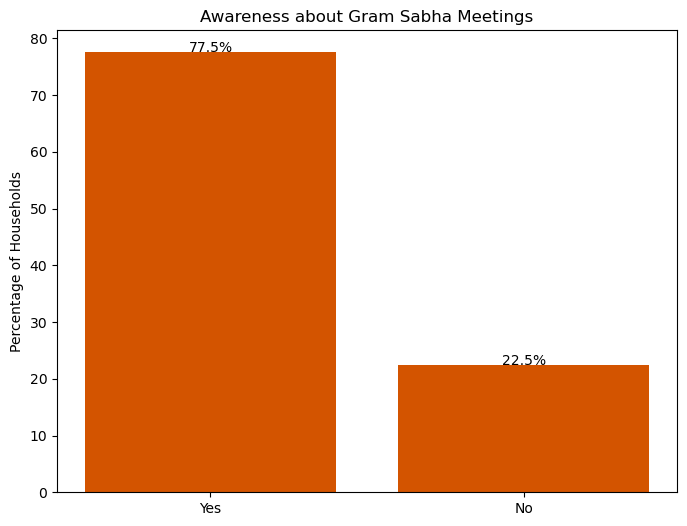

In [114]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_gram_sabha.index, percentage_gram_sabha.values, color='#D35400')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Awareness about Gram Sabha Meetings")
plt.ylabel("Percentage of Households")
plt.show()

# Women Decision-Making Power

In [115]:
decision = df['Role of women in decision-making'].value_counts()
decision

Role of women in decision-making
Moderate    55
High        28
Low          6
Name: count, dtype: int64

In [116]:
percentage_decision = round(df['Role of women in decision-making'].value_counts(normalize=True)*100,2)
percentage_decision

Role of women in decision-making
Moderate    61.80
High        31.46
Low          6.74
Name: proportion, dtype: float64

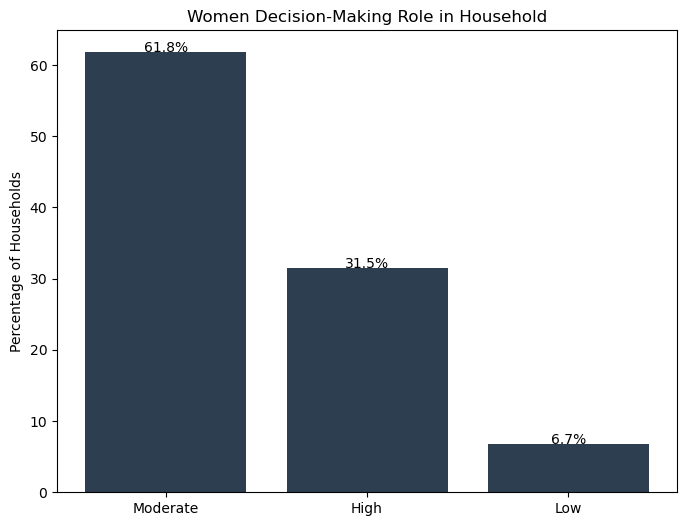

In [117]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_decision.index, percentage_decision.values, color='#2C3E50')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Women Decision-Making Role in Household")
plt.ylabel("Percentage of Households")
plt.show()

# Strategie Gap Analysis (Qualitative to Quantitative)

# 1. Urgency Index (Most Urgent Village Needs)

In [118]:
print(df['Most urgent need of the village'])

0                                               Medical
1     Cleanliness and overflow situation of village ...
2                                             Hospital 
3                                     Waste management 
4                                   Unemployment issues
                            ...                        
84                                            Hospital 
85                                            Hospital 
86                                 Cleanliness of ponds
87                           Education and hospitality 
88                           Hospital and water supply 
Name: Most urgent need of the village, Length: 89, dtype: object


In [119]:
urgency = df['Most urgent need of the village'].value_counts()
urgency

Most urgent need of the village
Hospital                                              7
Sewage system                                         4
Medical                                               3
Waste management                                      3
Severage                                              2
                                                     ..
Dispensary needed                                     1
Flood control                                         1
Cleanliness and overflow situation of village pond    1
Dispensary                                            1
Hospital and water supply                             1
Name: count, Length: 71, dtype: int64

In [120]:
urgency.count()

np.int64(71)

In [121]:
urgency = df['Most urgent need of the village'].str.lower().str.strip()
urgency

0                                               medical
1     cleanliness and overflow situation of village ...
2                                              hospital
3                                      waste management
4                                   unemployment issues
                            ...                        
84                                             hospital
85                                             hospital
86                                 cleanliness of ponds
87                            education and hospitality
88                            hospital and water supply
Name: Most urgent need of the village, Length: 89, dtype: object

In [122]:
urgency_split = urgency.str.split(r'[,.]').explode().str.strip()
urgency_split

0                                               medical
1     cleanliness and overflow situation of village ...
2                                              hospital
3                                      waste management
4                                   unemployment issues
                            ...                        
84                                             hospital
85                                             hospital
86                                 cleanliness of ponds
87                            education and hospitality
88                            hospital and water supply
Name: Most urgent need of the village, Length: 104, dtype: object

In [123]:
urgency_split = urgency_split.replace('', pd.NA).dropna()
urgency_split

0                                               medical
1     cleanliness and overflow situation of village ...
2                                              hospital
3                                      waste management
4                                   unemployment issues
                            ...                        
84                                             hospital
85                                             hospital
86                                 cleanliness of ponds
87                            education and hospitality
88                            hospital and water supply
Name: Most urgent need of the village, Length: 98, dtype: object

In [124]:
urgency_values = urgency_split.value_counts()
urgency_values.head(10)

Most urgent need of the village
hospital                    8
waste water treatment       6
sewage system               4
flood control               4
medical                     3
waste management            3
drainage system             3
education                   2
dispensary                  2
improved drainage system    2
Name: count, dtype: int64

In [125]:
category_map = {
    "hospital":"health",
    "hospitals":"health",
    "healthcare":"health",
    "health center":"health",
    "health facilities":"health",
    "medical":"health",
    "dispensary":"health",
    
    "roads":"roads",
    "road":"roads",
    "better roads":"roads",
    "road repair":"roads",
    "road development":"roads",
    "roads development":"roads",
    "good roads":"roads",
    
    "drainage":"sanitation",
    "drainage system":"sanitation",
    "sewage":"sanitation",
    "sewerage":"sanitation",
    "sewerage system":"sanitation",
    "sewage system":"sanitation",
    "severage":"sanitation",
    "waste management":"sanitation",
    "waste water treatment":"sanitation",
    
    "water":"water",
    "clean water":"water",
    "water supply":"water",
    "water management":"water",
    
    "school":"education",
    "education services":"education",
    
    "transport":"transport",
    "travelling":"transport",
    
    "cleaning":"cleanliness",
    "cleanliness":"cleanliness",
    "cleanness":"cleanliness"}

In [126]:
urgency_clean = urgency_split.replace(category_map)
urgency_summary = urgency_clean.value_counts()
urgency_summary.head(10)

Most urgent need of the village
sanitation                                                                                                      19
health                                                                                                          15
flood control                                                                                                    4
education                                                                                                        3
improved drainage system                                                                                         2
water                                                                                                            2
education and health service                                                                                     1
hospital should be built as the nearest hospital near this place is around 5kms which is really inconvenient     1
transport infrastructure                        

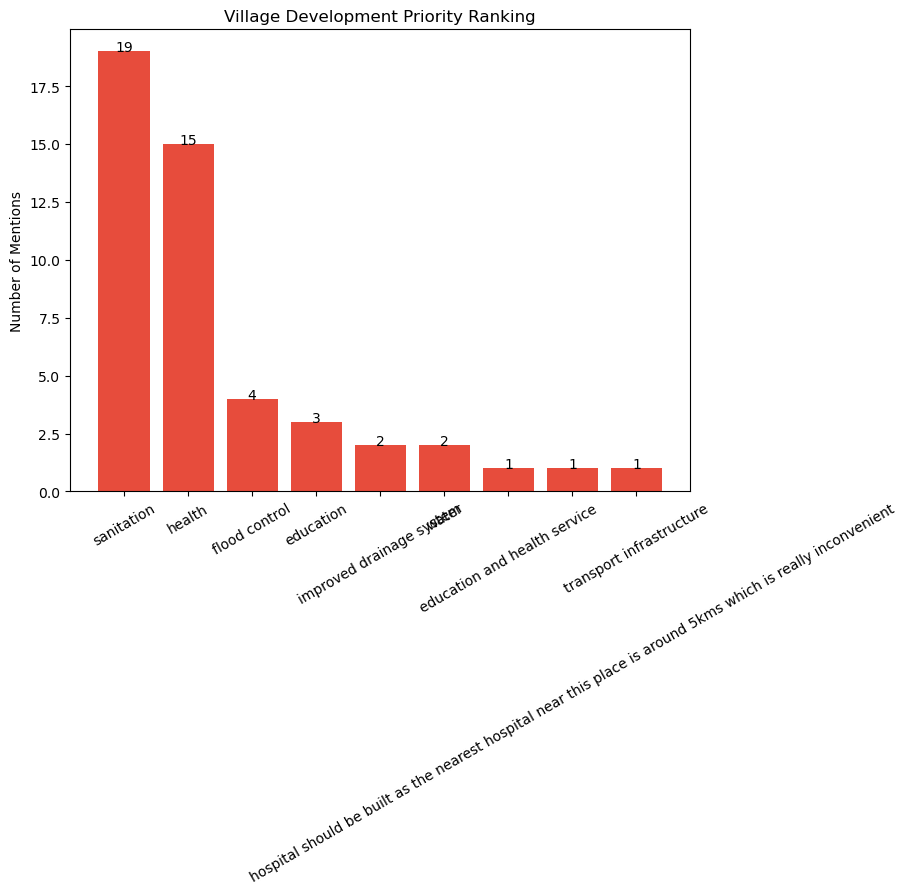

In [127]:
plt.figure(figsize=(8,6))
bars = plt.bar(urgency_summary.head(9).index, urgency_summary.head(9).values, color='#E74C3C')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height()}",
             ha='center')
plt.title("Village Development Priority Ranking")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=30)
plt.show()

# 2. Skill Gap Analysis

In [128]:
skill_trained = df['Skill-trained member in household'].value_counts()
skill_trained

Skill-trained member in household
Yes    54
No     35
Name: count, dtype: int64

In [129]:
percentage_skill_trained = round(df['Skill-trained member in household'].value_counts(normalize=True)*100,2)
percentage_skill_trained

Skill-trained member in household
Yes    60.67
No     39.33
Name: proportion, dtype: float64

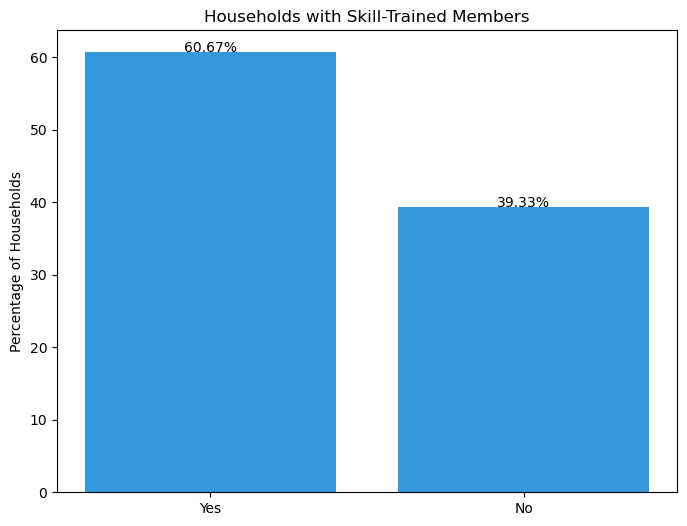

In [130]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_skill_trained.index, percentage_skill_trained.values, color='#3498DB')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}%",
             ha='center')
plt.title("Households with Skill-Trained Members")
plt.ylabel("Percentage of Households")
plt.show()

In [131]:
df['Skills required'].value_counts()

Skills required
Agriculture                                              23
Tailoring                                                20
Computer                                                 18
Tailoring, Computer                                       5
Electrical                                                4
Driving                                                   3
Agriculture, Tailoring                                    3
Agriculture, Tailoring, Computer, Electrical, Driving     2
Agriculture, Tailoring, Electrical, Driving               2
Agriculture, Driving                                      2
Agriculture, Tailoring, Computer, Driving                 2
Agriculture, Tailoring, Driving                           1
Agriculture, Tailoring, Computer                          1
Agriculture, Computer                                     1
Agriculture, Electrical, Driving                          1
Tailoring, Computer, Driving                              1
Name: count, dtype: int6

In [132]:
skills_required = df['Skills required'].str.split(',').explode().str.strip()

In [133]:
skills_required_counts = skills_required.value_counts()
skills_required_counts

Skills required
Agriculture    38
Tailoring      37
Computer       30
Driving        14
Electrical      9
Name: count, dtype: int64

In [134]:
percentage_skills_required = round(skills_required.value_counts(normalize=True)*100,2)
percentage_skills_required

Skills required
Agriculture    29.69
Tailoring      28.91
Computer       23.44
Driving        10.94
Electrical      7.03
Name: proportion, dtype: float64

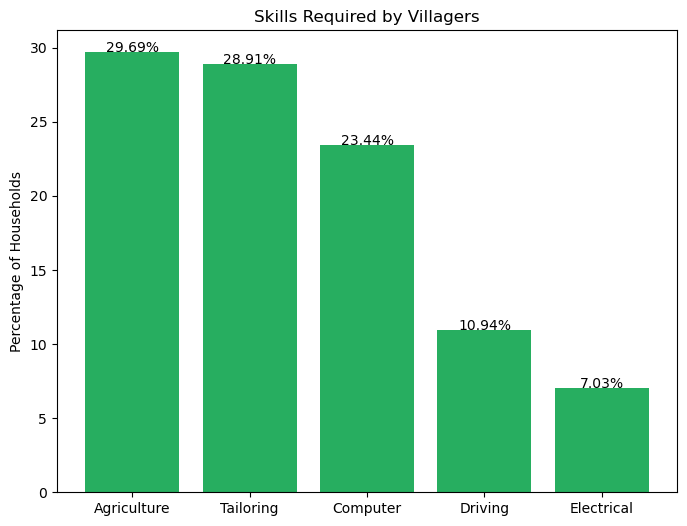

In [135]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_skills_required.index, percentage_skills_required.values, color='#27AE60')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}%",
             ha='center')
plt.title("Skills Required by Villagers")
plt.ylabel("Percentage of Households")
plt.show()

# A. Poverty–Education–Migration Cycle Analysis

# 1. Income vs School Dropout (Poverty → Education)

In [136]:
income_dropout = pd.crosstab(df['Approx. Annual Household Income'], df['School dropout cases  in the household'], normalize='index') * 100
income_dropout

School dropout cases in the household,NO,Partia,YES
Approx. Annual Household Income,,,
<1 lakh,70.370370,0.000000,29.629630
1-3 lakh,86.956522,8.695652,4.347826
3-5 lakh,88.000000,4.000000,8.000000
>5 lakh,71.428571,0.000000,28.571429


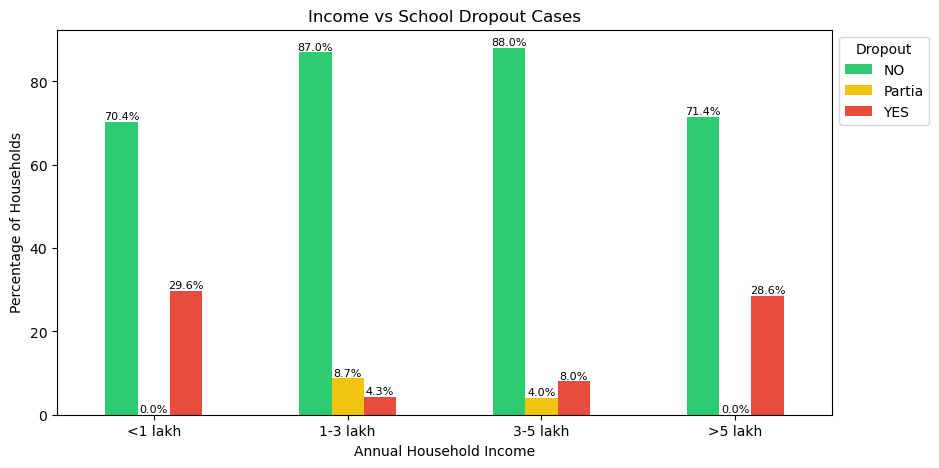

In [137]:
bars = income_dropout.plot(kind='bar', figsize=(10,5), color=['#2ECC71','#F1C40F','#E74C3C'])
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f"{bar.get_height():.1f}%",
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Income vs School Dropout Cases")
plt.ylabel("Percentage of Households")
plt.xlabel("Annual Household Income")
plt.xticks(rotation=0)
plt.legend(title="Dropout", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. Migration vs Reason for Dropout (Drivers)

In [138]:
migration_dropout_reason = round(pd.crosstab(df['Migration for employment'], df['Reason for dropout'], normalize='index') * 100,2)
migration_dropout_reason

Reason for dropout,Domestic work,Financial,Lack of interest,Migration
Migration for employment,,,,
Permanent,0.00,66.67,0.00,33.33
Seasonal,28.57,42.86,28.57,0.00


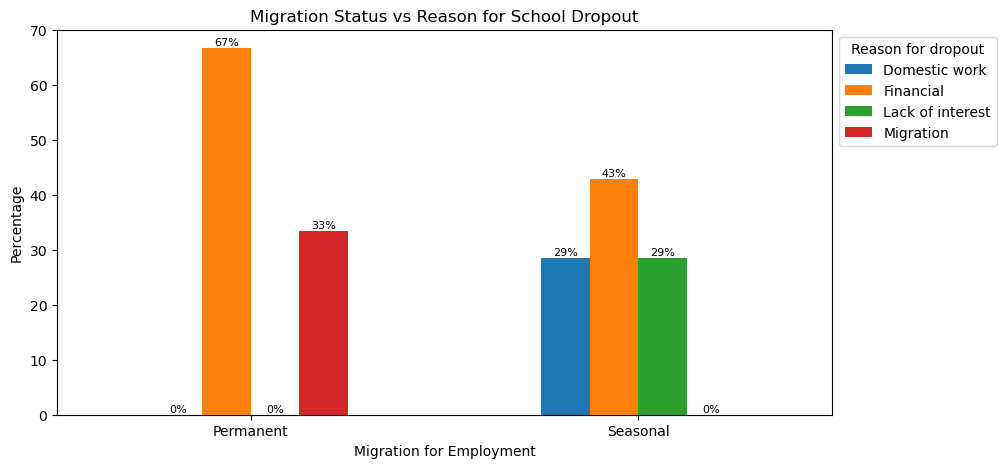

In [139]:
bars = migration_dropout_reason.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f"{bar.get_height():.0f}%",
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Migration Status vs Reason for School Dropout")
plt.ylabel("Percentage")
plt.xlabel("Migration for Employment")
plt.xticks(rotation=0)
plt.legend(title="Reason for dropout", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. Literacy vs Migration (Outcome)

In [140]:
literacy_migration = round(pd.crosstab(df['Literacy status of household'], df['Migration for employment'], normalize='index') * 100,2)
literacy_migration

Migration for employment,Permanent,Seasonal
Literacy status of household,,
All literate,20.00,80.00
Mostly illiterate,33.33,66.67
Partially literate,35.71,64.29


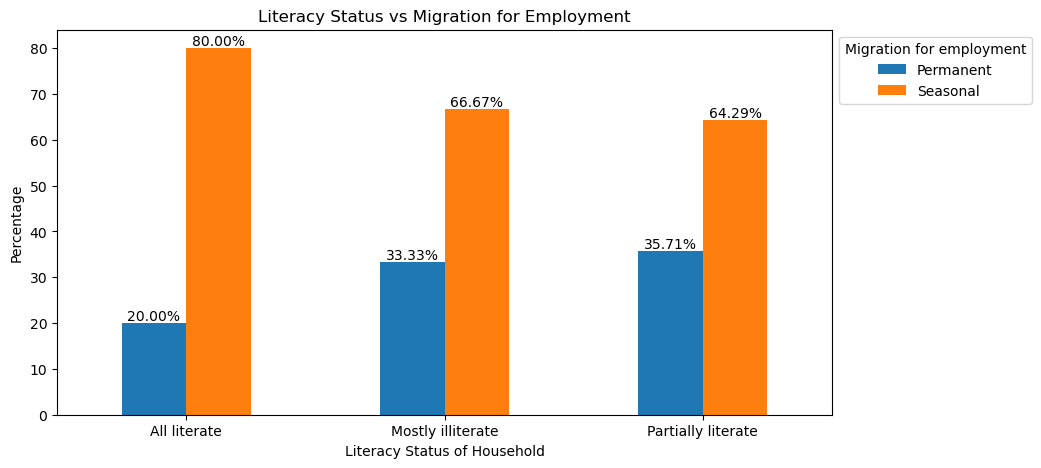

In [141]:
bars = literacy_migration.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.2f}%',
             ha='center',
             va='bottom')
plt.title("Literacy Status vs Migration for Employment")
plt.ylabel("Percentage")
plt.xlabel("Literacy Status of Household")
plt.xticks(rotation=0)
plt.legend(title="Migration for employment", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

In [142]:
round(pd.crosstab([df['Approx. Annual Household Income'], df['Migration for employment']], df['School dropout cases  in the household'], 
            normalize='index') * 100, 2)

School dropout cases  in the household                       NO  Partia    YES
Approx. Annual Household Income Migration for employment                      
<1 lakh                         Permanent                  50.0     0.0   50.0
                                Seasonal                   62.5     0.0   37.5
1-3 lakh                        Permanent                  75.0     0.0   25.0
                                Seasonal                  100.0     0.0    0.0
3-5 lakh                        Permanent                   0.0   100.0    0.0
                                Seasonal                  100.0     0.0    0.0
>5 lakh                         Permanent                   0.0     0.0  100.0
                                Seasonal                  100.0     0.0    0.0

# Social Equity in Public Service Delivery

# 1. Health Access Inequality

# Social Category vs Type of Health Facility Used

In [143]:
health_access = round(pd.crosstab(df['Social Category'], df['Type of facility used'], normalize='index') * 100,2)
health_access

Type of facility used,CHC,PHC,Private,Sub-Centre
Social Category,,,,
General,6.98,25.58,30.23,37.21
OBC,4.35,65.22,17.39,13.04
Scheduled Caste,4.76,28.57,42.86,23.81
Scheduled Tribe,0.00,50.00,0.00,50.00


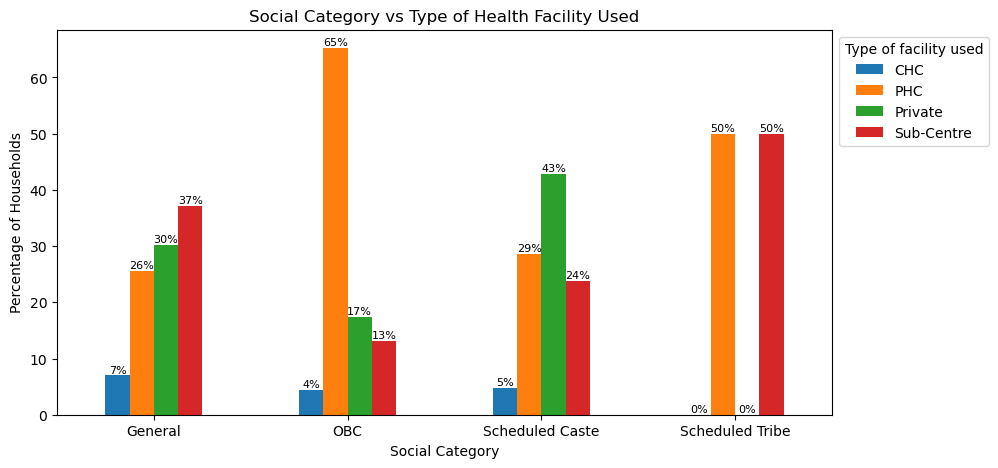

In [144]:
bars = health_access.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Social Category vs Type of Health Facility Used")
plt.ylabel("Percentage of Households")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Type of facility used", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Social Category vs ASHA/ANM Visits

In [145]:
asha_visits = round(pd.crosstab(df['Social Category'], df['ASHA/ANM visit'], normalize='index') * 100, 2)
asha_visits

ASHA/ANM visit,Never,Occasional,Regular
Social Category,,,
General,11.63,20.93,67.44
OBC,8.70,21.74,69.57
Scheduled Caste,14.29,14.29,71.43
Scheduled Tribe,0.00,50.00,50.00


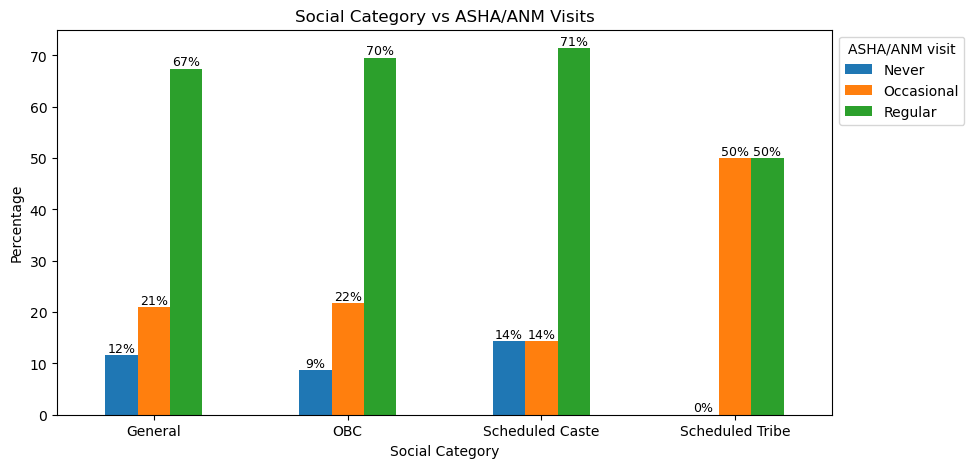

In [146]:
bars = asha_visits.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=9)
plt.title("Social Category vs ASHA/ANM Visits")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="ASHA/ANM visit", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. Scheme Reach (Equity in Government Benefits)

# Social Category vs PM-JAY (Ayushman Bharat)

In [147]:
pmjay_access = round(pd.crosstab(df['Social Category'], df['Health Schemes   [Ayushman Bharat (PM-JAY)]'], normalize='index') * 100, 2)
pmjay_access

Health Schemes [Ayushman Bharat (PM-JAY)],Applied,Availed,Aware,Not aware
Social Category,,,,
General,6.98,4.65,55.81,32.56
OBC,17.39,4.35,47.83,30.43
Scheduled Caste,0.00,4.76,57.14,38.10
Scheduled Tribe,0.00,0.00,50.00,50.00


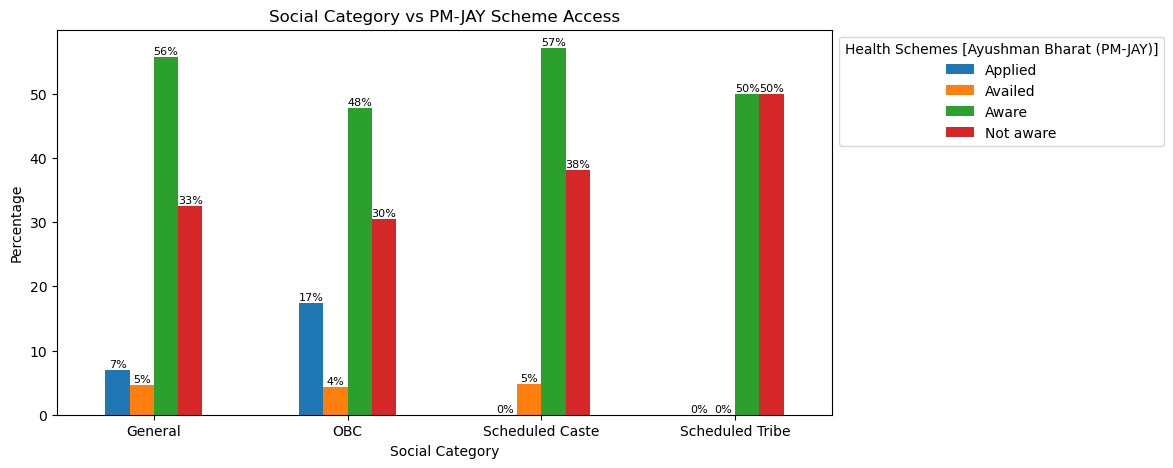

In [148]:
bars = pmjay_access.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Social Category vs PM-JAY Scheme Access")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Health Schemes [Ayushman Bharat (PM-JAY)]", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Social Category vs MGNREGA

In [149]:
mgnrega_access = round(pd.crosstab(df['Social Category'], df['Livelihood Schemes   [MGNREGA]'], normalize='index') * 100, 2)
mgnrega_access

Livelihood Schemes [MGNREGA],Applied,Availed,Aware,Not Aware
Social Category,,,,
General,0.00,9.30,53.49,37.21
OBC,4.35,0.00,56.52,39.13
Scheduled Caste,0.00,9.52,66.67,23.81
Scheduled Tribe,0.00,0.00,50.00,50.00


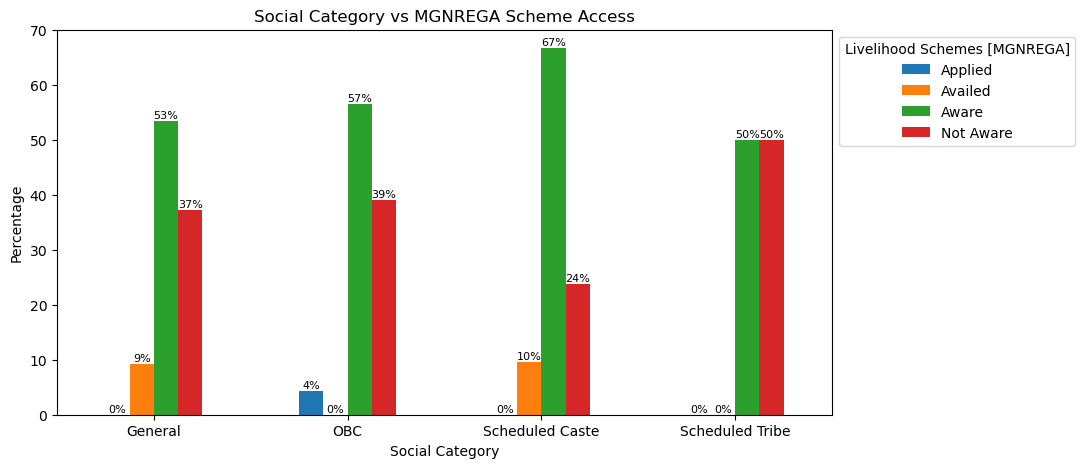

In [150]:
bars = mgnrega_access.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Social Category vs MGNREGA Scheme Access")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Livelihood Schemes [MGNREGA]", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. Digital Divide Analysis

# Social Category vs Access to Digital Devices

In [151]:
digital_divide = round(pd.crosstab(df['Social Category'], df['Access to digital devices'], normalize='index') * 100, 2)
digital_divide

Access to digital devices,Laptop,Smartphone,"Smartphone, Laptop"
Social Category,,,
General,0.0,82.50,17.50
OBC,0.0,54.55,45.45
Scheduled Caste,0.0,78.95,21.05
Scheduled Tribe,50.0,50.00,0.00


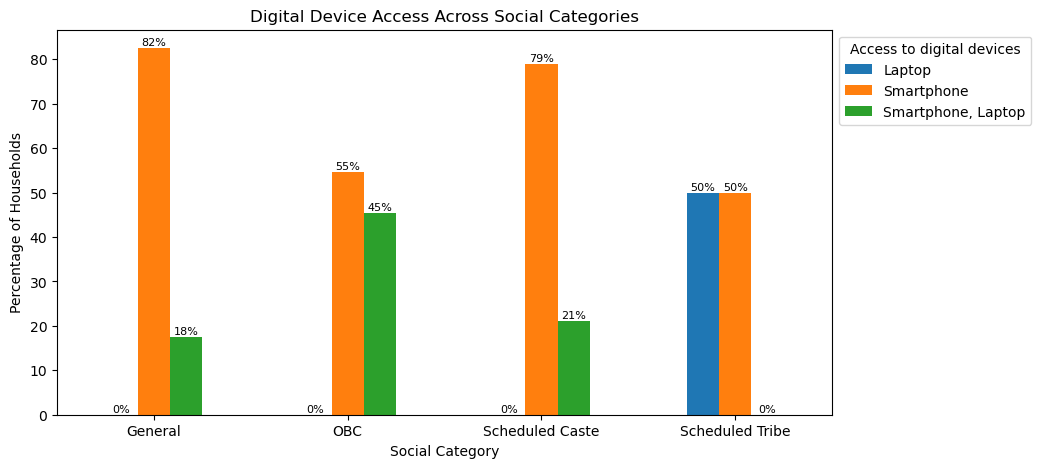

In [152]:
bars = digital_divide.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Digital Device Access Across Social Categories")
plt.ylabel("Percentage of Households")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Access to digital devices", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Women's Economic Agency vs. Decision-Making Power

# 1. Income Activity vs Decision-Making Power

In [153]:
decision_income = round(pd.crosstab(df['Household women  engaged in income activity'], df['Role of women in decision-making'], normalize='index') 
                        * 100, 2)
decision_income

Role of women in decision-making,High,Low,Moderate
Household women engaged in income activity,,,
No,30.65,6.45,62.90
Yes,33.33,7.41,59.26


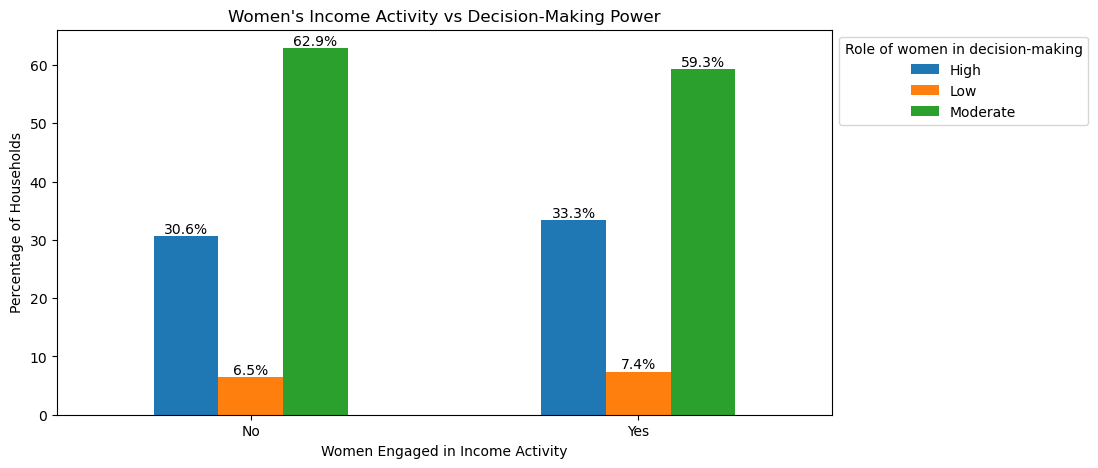

In [154]:
bars = decision_income.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Women's Income Activity vs Decision-Making Power")
plt.ylabel("Percentage of Households")
plt.xlabel("Women Engaged in Income Activity")
plt.xticks(rotation=0)
plt.legend(title="Role of women in decision-making", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. SHG Membership vs Decision-Making Power

In [155]:
shg_decision = round(pd.crosstab(df['SHG membership'], df['Role of women in decision-making'], normalize='index') * 100, 2)
shg_decision

Role of women in decision-making,High,Low,Moderate
SHG membership,,,
No,30.00,7.5,62.50
Yes,44.44,0.0,55.56


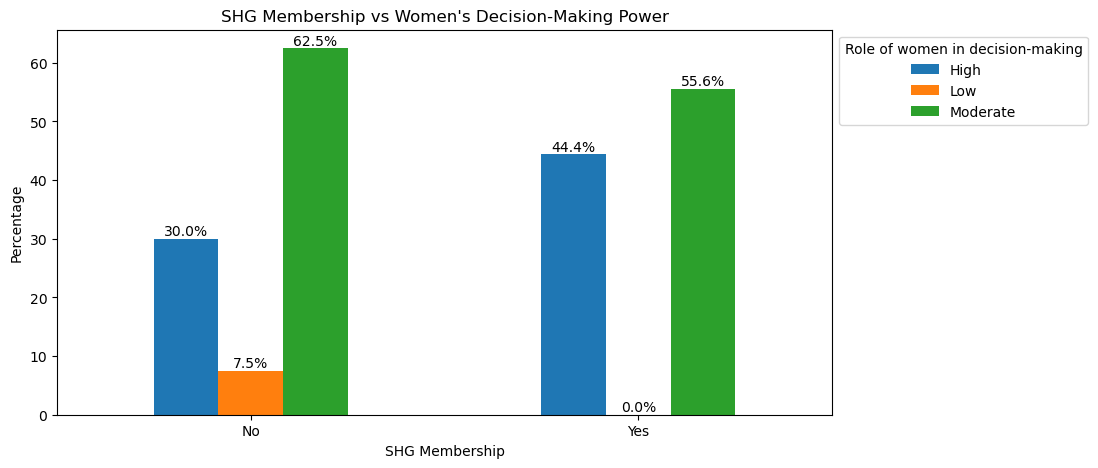

In [156]:
bars = shg_decision.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("SHG Membership vs Women's Decision-Making Power")
plt.ylabel("Percentage")
plt.xlabel("SHG Membership")
plt.xticks(rotation=0)
plt.legend(title="Role of women in decision-making", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. SHG Membership vs Awareness of Women Schemes

In [157]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [NRLM]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [NRLM],Availed,Aware,Not Aware
SHG membership,,,
No,5.0,35.00,60.00
Yes,0.0,66.67,33.33


In [158]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [Pradhan Mantri Matru Vandana Yojana]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [Pradhan Mantri Matru Vandana Yojana],Applied,Availed,Aware,Not Aware
SHG membership,,,,
No,1.25,2.5,40.00,56.25
Yes,0.00,0.0,77.78,22.22


In [159]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [Beti Bachao Beti Padhao]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [Beti Bachao Beti Padhao],Applied,Availed,Aware,Not Aware
SHG membership,,,,
No,8.75,2.5,62.50,26.25
Yes,0.00,0.0,77.78,22.22


In [160]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [Sukanya Samriddhi]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [Sukanya Samriddhi],Applied,Availed,Aware,Not Aware
SHG membership,,,,
No,2.5,3.75,38.75,55.00
Yes,0.0,0.00,77.78,22.22


# Health Outcomes and Environmental Sanitation

# 1. Environmental Link

In [161]:
pond_disease = round(pd.crosstab( df['Condition of pond'], df['Common diseases'], normalize='index') * 100,2)
pond_disease

Common diseases,BP,"BP, Diabetes","BP, Diabetes, Respiratory",Diabetes,"Diabetes, None",TB
Condition of pond,,,,,,
Clean,50.00,0.00,0.00,50.00,0.00,0.00
Highly polluted,42.42,36.36,3.03,12.12,3.03,3.03
Partially polluted,66.67,22.22,11.11,0.00,0.00,0.00


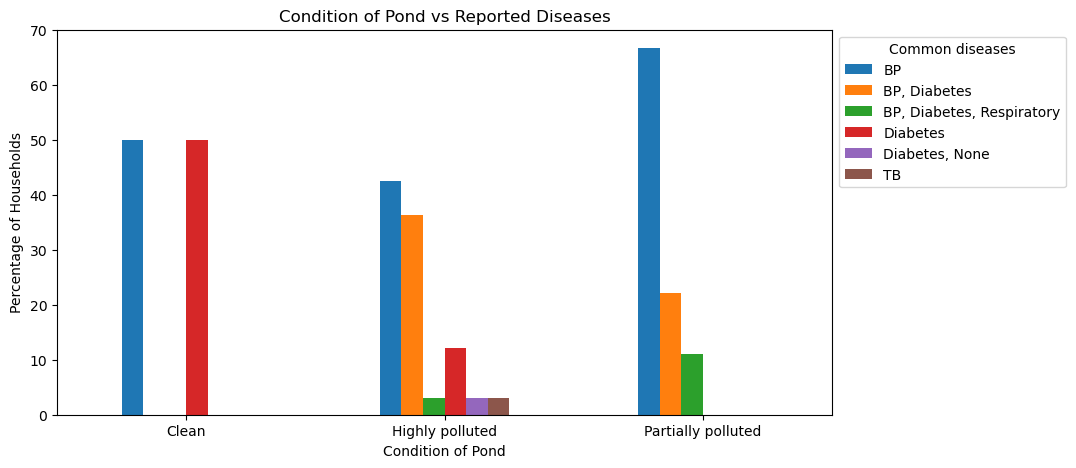

In [162]:
pond_disease.plot(kind='bar', figsize=(10,5))
plt.title("Condition of Pond vs Reported Diseases")
plt.ylabel("Percentage of Households")
plt.xlabel("Condition of Pond")
plt.xticks(rotation=0)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. Solid Waste Disposal vs Diseases

In [163]:
waste_disease = round(pd.crosstab(df['Solid waste disposal method'], df['Common diseases'], normalize='index') * 100, 2)
waste_disease

Common diseases,BP,"BP, Diabetes","BP, Diabetes, Respiratory",Diabetes,"Diabetes, None",TB
Solid waste disposal method,,,,,,
Door-to-door,0.00,66.67,0.00,33.33,0.00,0.00
Open dumping,57.58,24.24,3.03,9.09,3.03,3.03
"Open dumping, Burning",25.00,50.00,12.50,12.50,0.00,0.00


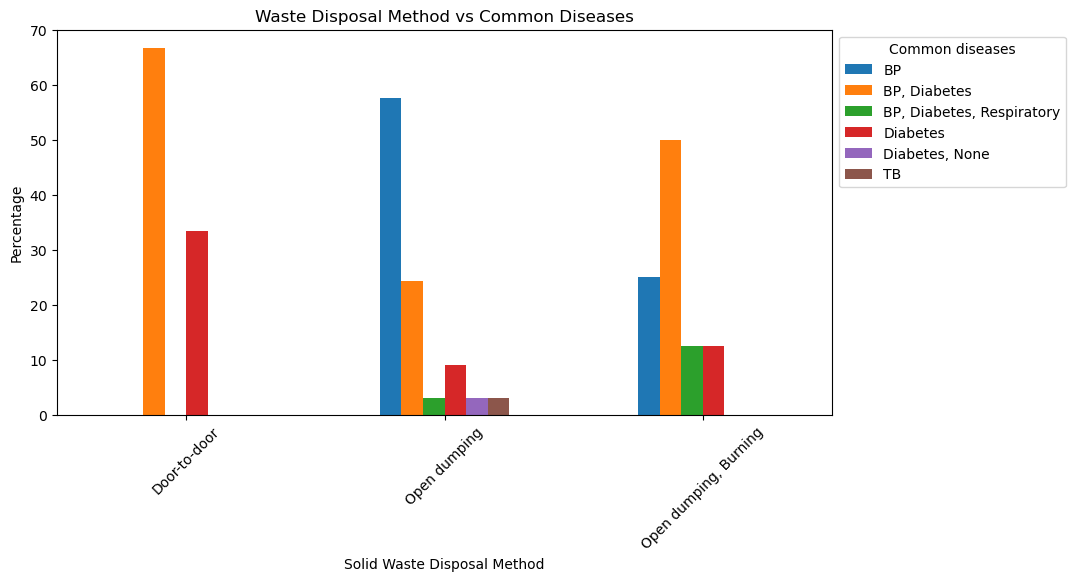

In [164]:
waste_disease.plot(kind='bar', figsize=(10,5))
plt.title("Waste Disposal Method vs Common Diseases")
plt.ylabel("Percentage")
plt.xlabel("Solid Waste Disposal Method")
plt.xticks(rotation=45)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. Hygiene Practices vs Diseases

In [165]:
handwash_disease = round(pd.crosstab(df['Handwashing with soap'], df['Common diseases'], normalize='index') * 100, 2)
handwash_disease

Common diseases,BP,"BP, Diabetes","BP, Diabetes, Respiratory",Diabetes,"Diabetes, None",TB
Handwashing with soap,,,,,,
Always,43.9,34.15,4.88,12.2,2.44,2.44
Sometimes,100.0,0.00,0.00,0.0,0.00,0.00


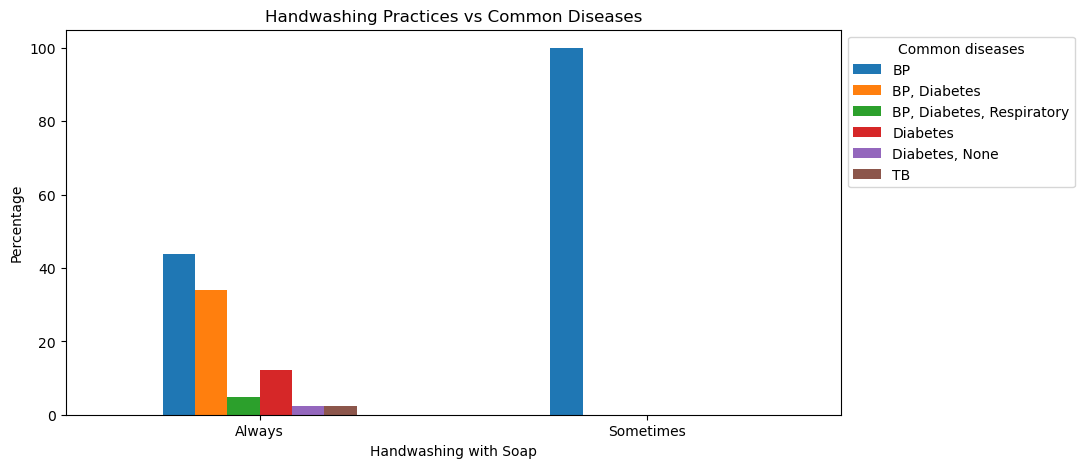

In [166]:
handwash_disease.plot(kind='bar', figsize=(10,5))
plt.title("Handwashing Practices vs Common Diseases")
plt.ylabel("Percentage")
plt.xlabel("Handwashing with Soap")
plt.xticks(rotation=0)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

In [167]:
toilet_disease = round(pd.crosstab(df['Toilet availability'], df['Common diseases'], normalize='index') * 100, 2)
toilet_disease

Common diseases,BP,"BP, Diabetes","BP, Diabetes, Respiratory",Diabetes,"Diabetes, None",TB
Toilet availability,,,,,,
YES,47.73,31.82,4.55,11.36,2.27,2.27


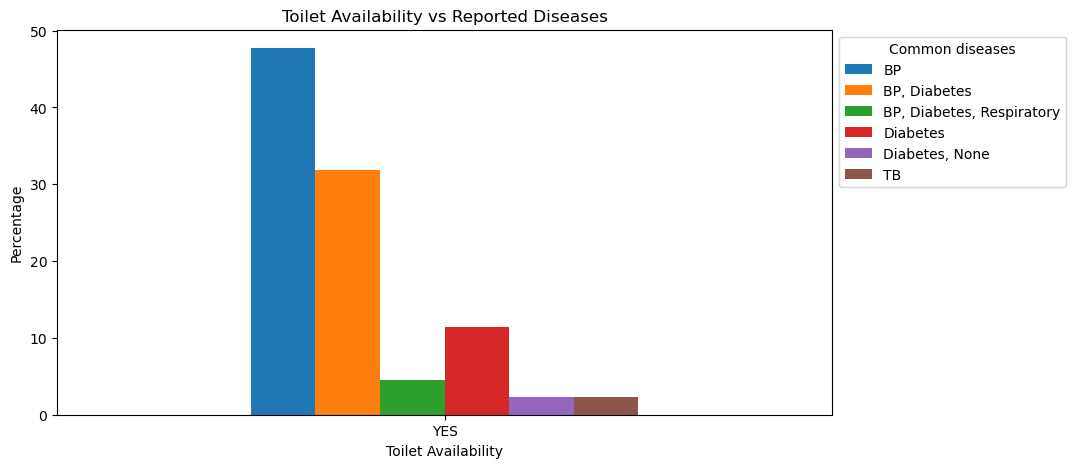

In [168]:
toilet_disease.plot(kind='bar', figsize=(10,5))
plt.title("Toilet Availability vs Reported Diseases")
plt.ylabel("Percentage")
plt.xlabel("Toilet Availability")
plt.xticks(rotation=0)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Infrastructure Accessibility & Service Utilization

# 1. Distance to Health Facility vs Immunization Status

In [169]:
health_distance_immunization = round(pd.crosstab(df['Distance to nearest health facility'], df['Immunization status of children (0-5)'], 
                                                 normalize='index') * 100, 2)
health_distance_immunization

Immunization status of children (0-5),Fully,Not immunised,Partially
Distance to nearest health facility,,,
1-5 km,93.33,3.33,3.33
<1 km,71.43,23.81,4.76
>5 km,97.37,0.00,2.63


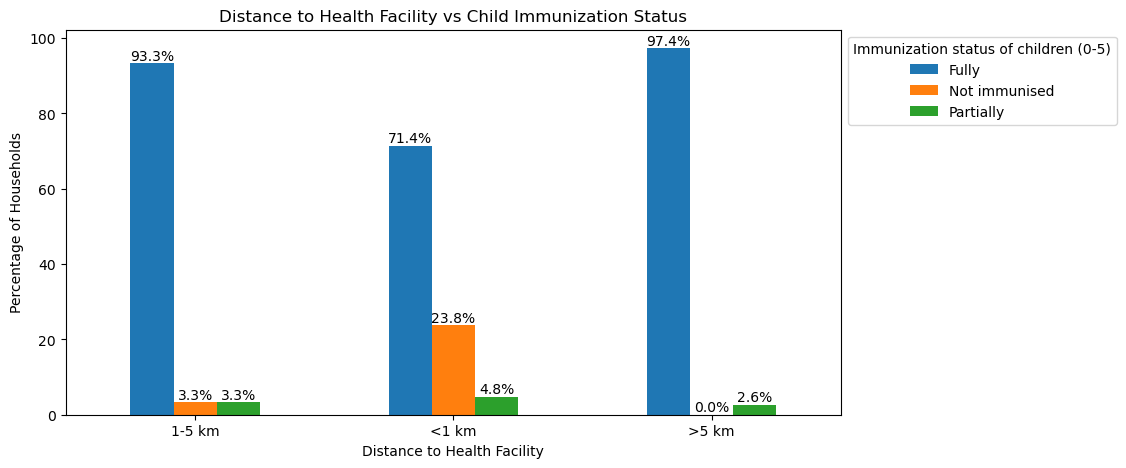

In [170]:
bars = health_distance_immunization.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Distance to Health Facility vs Child Immunization Status")
plt.ylabel("Percentage of Households")
plt.xlabel("Distance to Health Facility")
plt.legend(title='Immunization status of children (0-5)', bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 2. Distance to School vs Girls' Education

In [171]:
school_distance_girls = round(pd.crosstab(df['Distance to nearest school'], df['Girls continuing education beyond Class X'], normalize='index') 
                              * 100, 2)
school_distance_girls

Girls continuing education beyond Class X,No,YES
Distance to nearest school,,
1-3 km,12.50,87.50
<1 km,13.33,86.67
>3 km,10.00,90.00


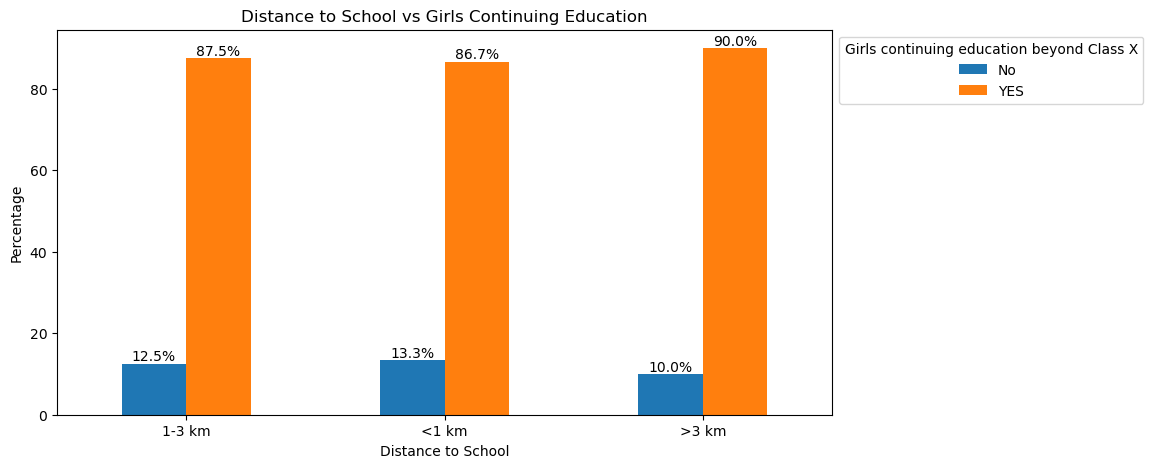

In [172]:
bars = school_distance_girls.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Distance to School vs Girls Continuing Education")
plt.ylabel("Percentage")
plt.xlabel("Distance to School")
plt.legend(title="Girls continuing education beyond Class X", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 3. Behavioral Shift in Healthcare Choice

In [173]:
distance_facility_type = round(pd.crosstab(df['Distance to nearest health facility'], df['Type of facility used'], normalize='index') * 100, 2)
distance_facility_type

Type of facility used,CHC,PHC,Private,Sub-Centre
Distance to nearest health facility,,,,
1-5 km,10.00,56.67,16.67,16.67
<1 km,4.76,28.57,4.76,61.90
>5 km,2.63,26.32,52.63,18.42


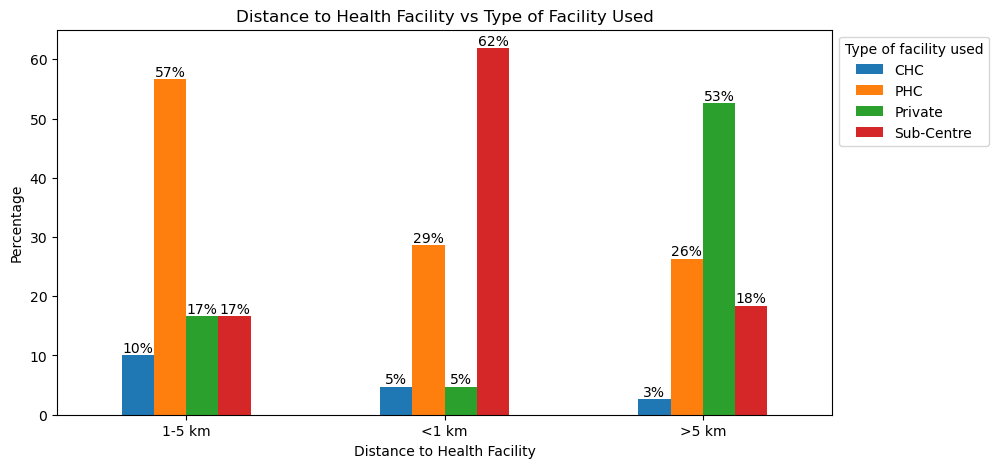

In [174]:
bars = distance_facility_type.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom')
plt.title("Distance to Health Facility vs Type of Facility Used")
plt.ylabel("Percentage")
plt.xlabel("Distance to Health Facility")
plt.legend(title="Type of facility used", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# Village Governance & Civic Engagement

# 1. Knowledge–Action Gap

In [175]:
awareness_participation = round(pd.crosstab(df['Awareness about Gram Sabha meetings'], df['Participation in village development'], normalize='index')
                                * 100, 2)
awareness_participation

Participation in village development,Never,Occasional,Regular
Awareness about Gram Sabha meetings,,,
No,50.00,45.00,5.00
Yes,18.84,34.78,46.38


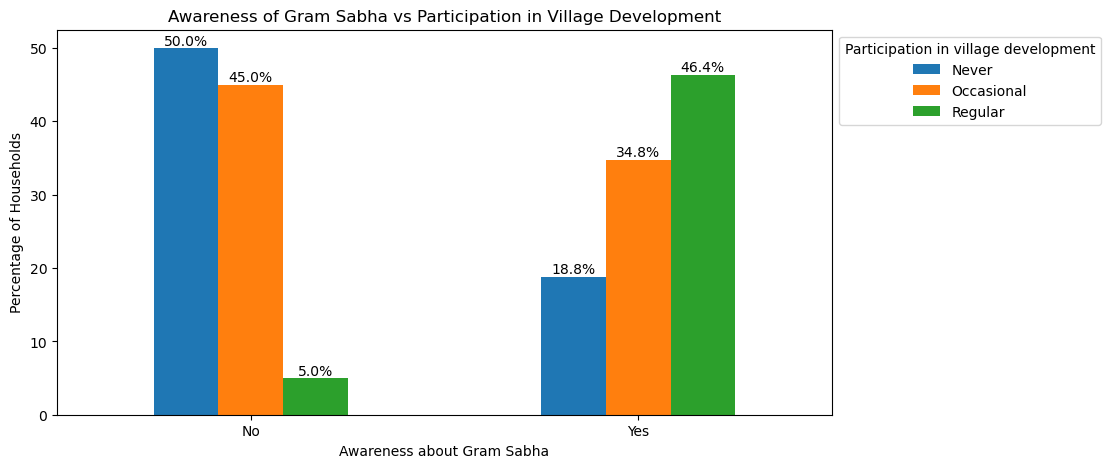

In [176]:
bars = awareness_participation.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Awareness of Gram Sabha vs Participation in Village Development")
plt.ylabel("Percentage of Households")
plt.xlabel("Awareness about Gram Sabha")
plt.legend(title="Participation in village development", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 2. Migration vs Participation

In [177]:
migration_participation = round(pd.crosstab(df['Migration for employment'], df['Participation in village development'], normalize='index') * 100, 2)
migration_participation

Participation in village development,Never,Occasional,Regular
Migration for employment,,,
Permanent,37.50,37.50,25.00
Seasonal,17.65,52.94,29.41


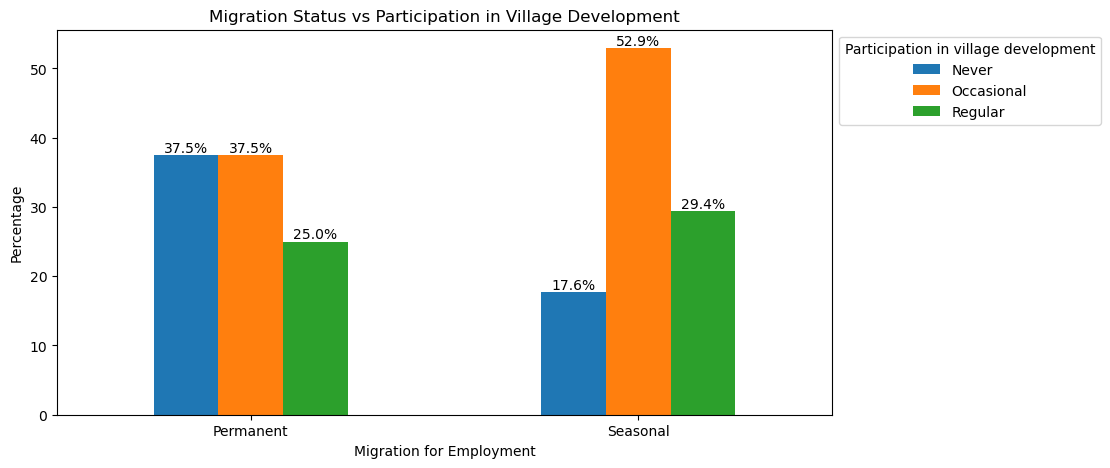

In [178]:
bars = migration_participation.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Migration Status vs Participation in Village Development")
plt.ylabel("Percentage")
plt.xlabel("Migration for Employment")
plt.legend(title="Participation in village development", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 3. Social Category vs Participation (Inclusion)

In [179]:
social_participation = round(pd.crosstab(df['Social Category'], df['Participation in village development'], normalize='index') * 100, 2)
social_participation

Participation in village development,Never,Occasional,Regular
Social Category,,,
General,20.93,37.21,41.86
OBC,34.78,21.74,43.48
Scheduled Caste,28.57,47.62,23.81
Scheduled Tribe,0.00,100.00,0.00


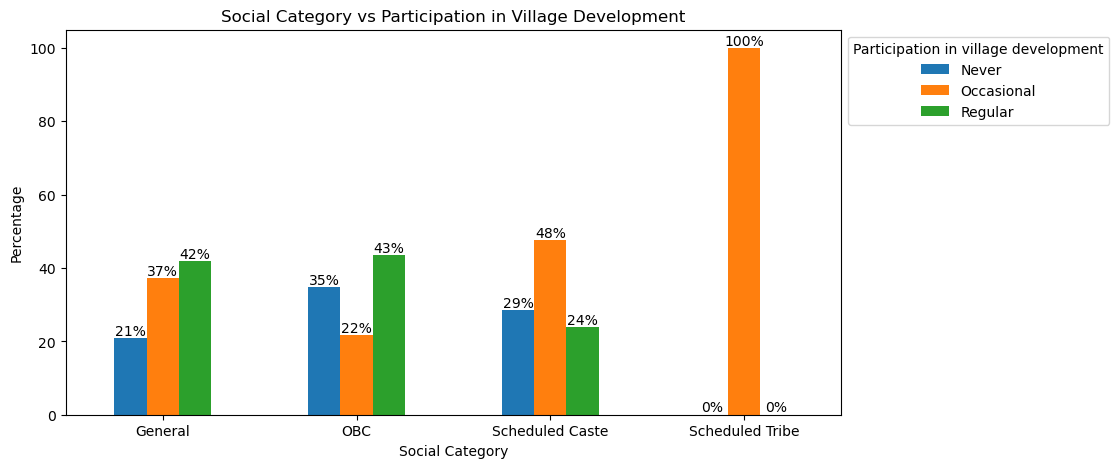

In [180]:
bars = social_participation.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom')
plt.title("Social Category vs Participation in Village Development")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.legend(title="Participation in village development", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# Skill-Demand Mismatch for Livelihoods

# 1. Skill Demand vs Current Occupation (Gap Analysis)

In [181]:
skill_occupation = pd.crosstab(df['Main Occupation'], df['Skills required'])
skill_occupation

Skills required,Agriculture,"Agriculture, Computer","Agriculture, Driving","Agriculture, Electrical, Driving","Agriculture, Tailoring","Agriculture, Tailoring, Computer","Agriculture, Tailoring, Computer, Driving","Agriculture, Tailoring, Computer, Electrical, Driving","Agriculture, Tailoring, Driving","Agriculture, Tailoring, Electrical, Driving",Computer,Driving,Electrical,Tailoring,"Tailoring, Computer","Tailoring, Computer, Driving"
Main Occupation,,,,,,,,,,,,,,,,
Agriculture,13,1,0,0,1,1,2,1,1,1,0,1,2,6,2,0
"Agriculture, Business",1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
"Agriculture, Labour",2,0,0,0,0,0,0,0,0,0,2,0,0,1,0,0
"Agriculture, Service",0,0,0,1,0,0,0,1,0,0,0,0,0,2,0,0
Business,0,0,0,0,0,0,0,0,0,0,6,1,0,1,3,0
Labour,5,0,1,0,2,0,0,0,0,0,3,1,1,7,0,0
"Labour, Service",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
Service,1,0,1,0,0,0,0,0,0,1,4,0,0,3,0,1
"Service, Business",1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0


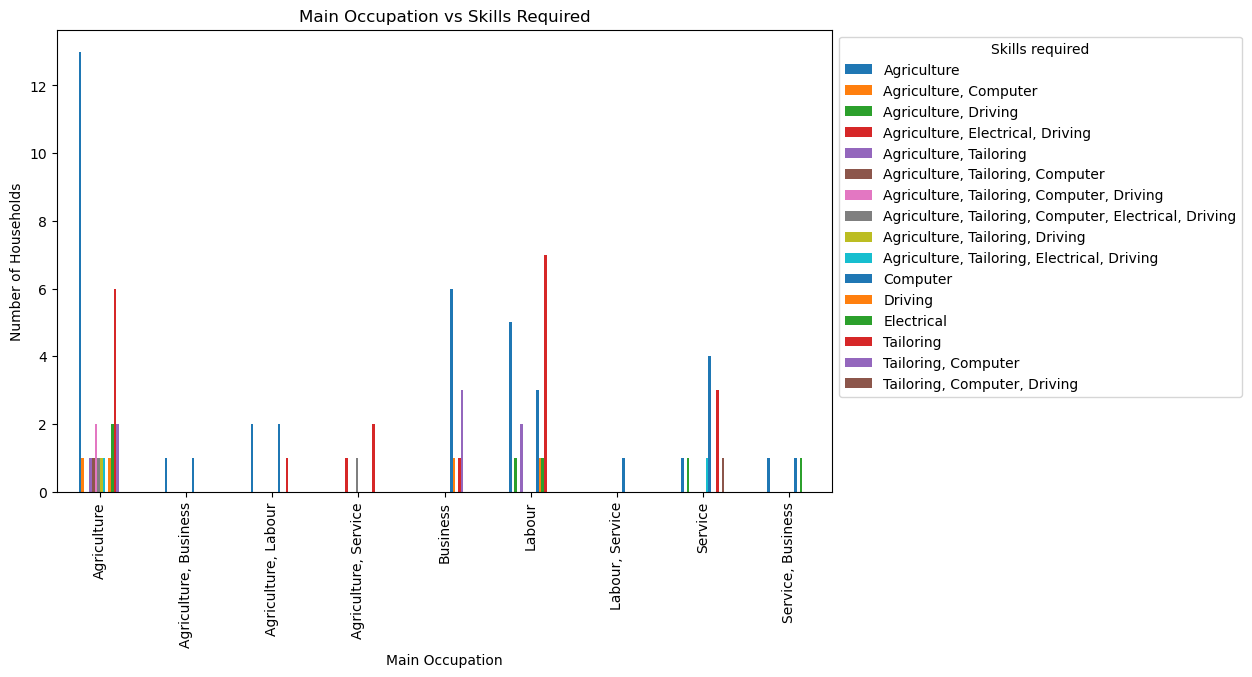

In [182]:
skill_occupation.plot(kind='bar', figsize=(10,6))
plt.title("Main Occupation vs Skills Required")
plt.ylabel("Number of Households")
plt.xlabel("Main Occupation")
plt.legend(title="Skills required", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=90)
plt.show()

# 2. Skill Training vs Household Income (Future Readiness)

In [183]:
skill_income = round(pd.crosstab(df['Skill-trained member in household'], df['Approx. Annual Household Income'], normalize='index') * 100, 2)
skill_income

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Skill-trained member in household,,,,
No,25.71,25.71,31.43,17.14
Yes,33.33,25.93,25.93,14.81


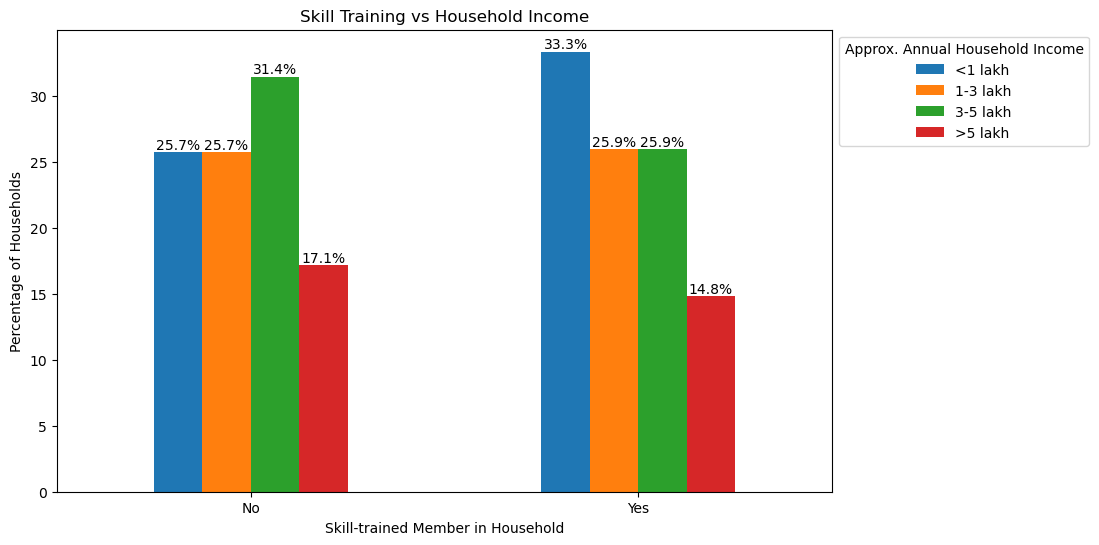

In [184]:
bars = skill_income.plot(kind='bar', figsize=(10,6))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Skill Training vs Household Income")
plt.ylabel("Percentage of Households")
plt.xlabel("Skill-trained Member in Household")
plt.legend(title="Approx. Annual Household Income", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 3. Skills Required Distribution

In [185]:
skills_demand = df['Skills required'].value_counts()
skills_demand

Skills required
Agriculture                                              23
Tailoring                                                20
Computer                                                 18
Tailoring, Computer                                       5
Electrical                                                4
Driving                                                   3
Agriculture, Tailoring                                    3
Agriculture, Tailoring, Computer, Electrical, Driving     2
Agriculture, Tailoring, Electrical, Driving               2
Agriculture, Driving                                      2
Agriculture, Tailoring, Computer, Driving                 2
Agriculture, Tailoring, Driving                           1
Agriculture, Tailoring, Computer                          1
Agriculture, Computer                                     1
Agriculture, Electrical, Driving                          1
Tailoring, Computer, Driving                              1
Name: count, dtype: int6

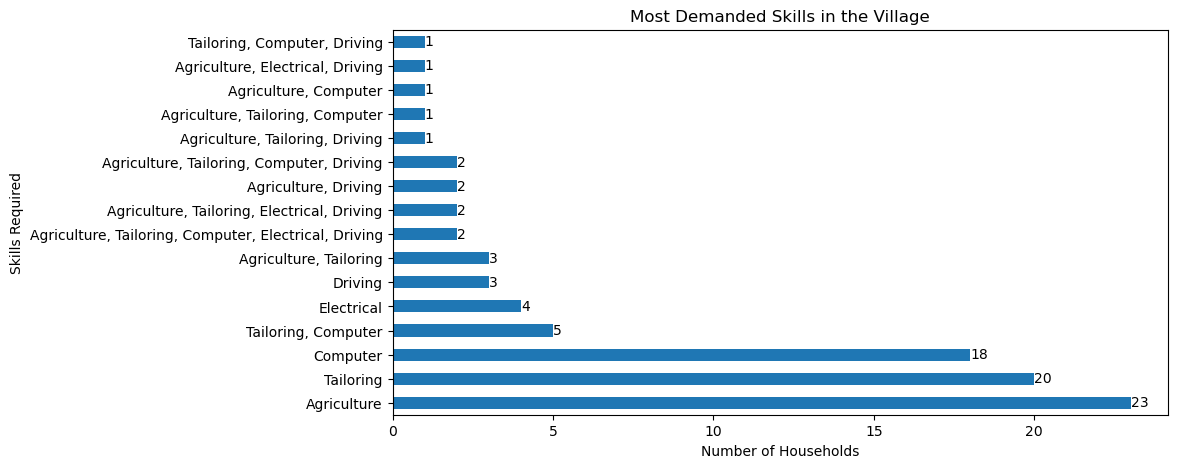

In [186]:
bars = skills_demand.plot(kind='barh', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_width(),
             bar.get_y()+ bar.get_height()/2,
             f'{bar.get_width()}',
             va='center')
plt.title("Most Demanded Skills in the Village")
plt.xlabel("Number of Households")
plt.ylabel("Skills Required")
plt.show()